# Volatility Models for S&P 500 Risk Management

This notebook explores various volatility modeling techniques for the S&P 500 index. Accurate volatility forecasting is crucial for risk management, options pricing, and developing trading strategies that can adapt to changing market conditions.

We'll cover:
1. Historical volatility calculations
2. GARCH models for volatility forecasting
3. Implied volatility analysis
4. Volatility regimes identification
5. Risk management applications
6. Volatility-based trading signals

## Setup and Data Collection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Download S&P 500 data (5 years)
sp500 = yf.download('^GSPC', auto_adjust=False, period='5y')

# Check the data
print(f"Data period: {sp500.index.min().date()} to {sp500.index.max().date()}")
print(f"Number of trading days: {len(sp500)}")
sp500.head()

[*********************100%***********************]  1 of 1 completed

Data period: 2020-05-04 to 2025-05-01
Number of trading days: 1256


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2020-05-04,2842.739990,2842.739990,2844.239990,2797.850098,2815.010010,4735930000
2020-05-05,2868.439941,2868.439941,2898.229980,2863.550049,2868.879883,5140290000
2020-05-06,2848.419922,2848.419922,2891.110107,2847.649902,2883.139893,4892570000
2020-05-07,2881.189941,2881.189941,2901.919922,2876.479980,2878.260010,5178790000
2020-05-08,2929.800049,2929.800049,2932.159912,2902.879883,2908.830078,4876030000


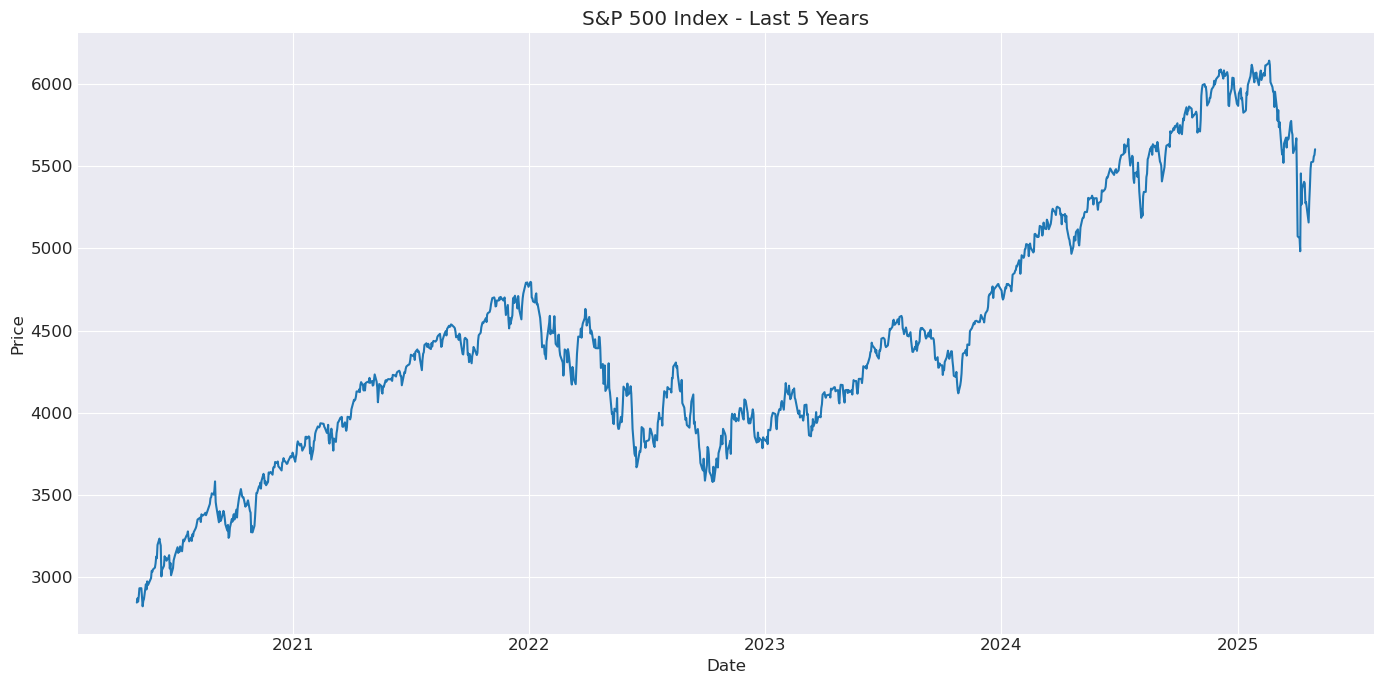

In [3]:
# Plot S&P 500 price history
plt.figure(figsize=(14, 7))
plt.plot(sp500.index, sp500['Close'])
plt.title('S&P 500 Index - Last 5 Years')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

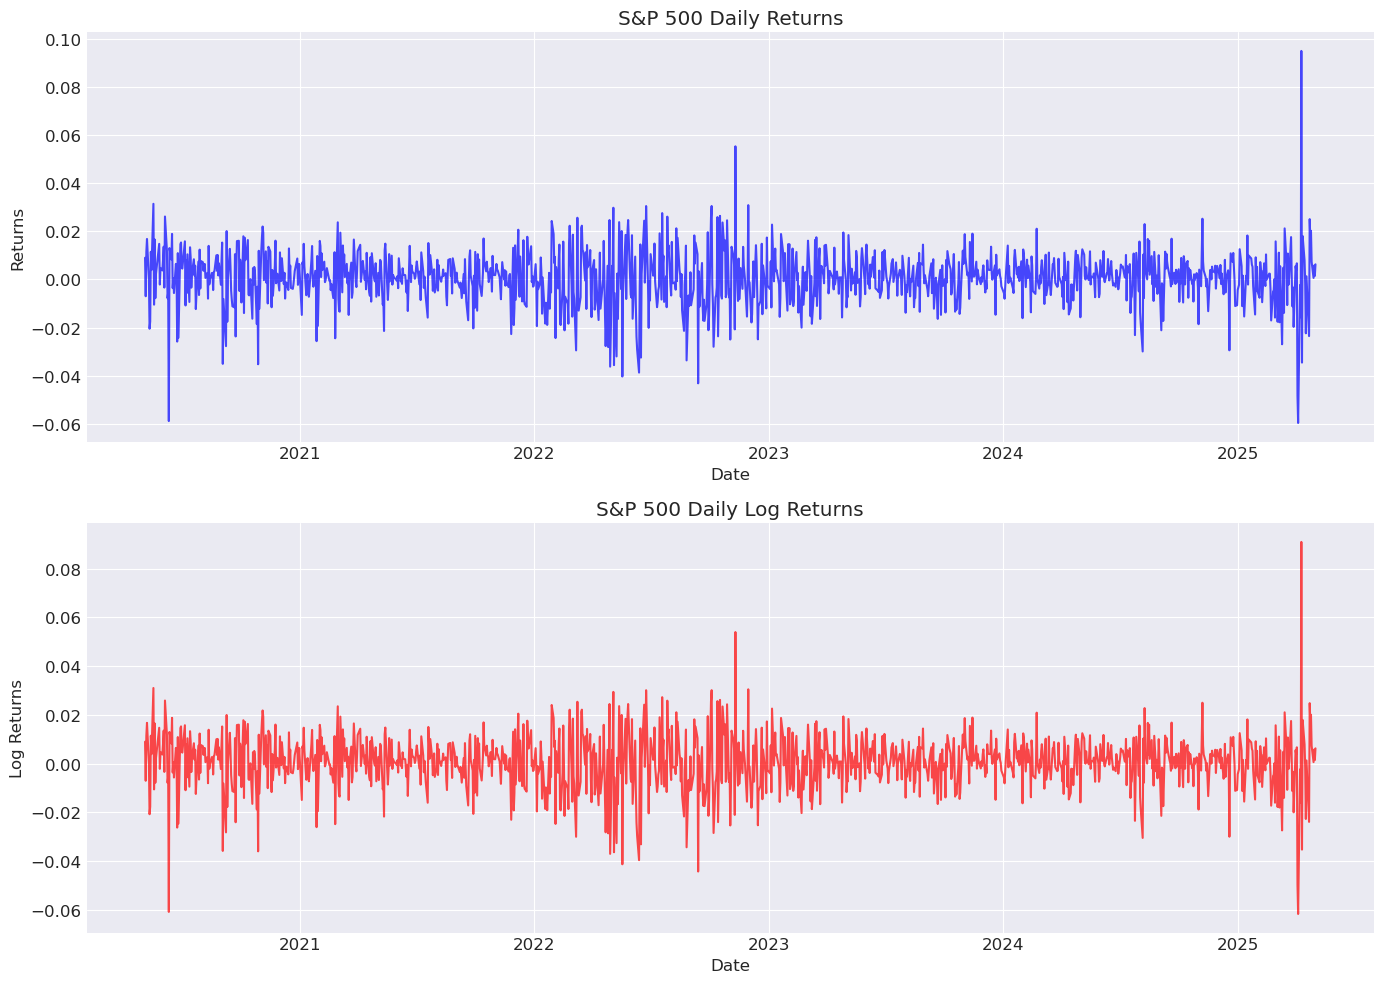

In [4]:
# Calculate daily returns
sp500['Returns'] = sp500['Close'].pct_change()
sp500['Log_Returns'] = np.log(sp500['Close'] / sp500['Close'].shift(1))

# Plot returns
fig, axs = plt.subplots(2, 1, figsize=(14, 10))

axs[0].plot(sp500.index[1:], sp500['Returns'][1:], 'b-', alpha=0.7)
axs[0].set_title('S&P 500 Daily Returns')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Returns')
axs[0].grid(True)

axs[1].plot(sp500.index[1:], sp500['Log_Returns'][1:], 'r-', alpha=0.7)
axs[1].set_title('S&P 500 Daily Log Returns')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Log Returns')
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 1. Historical Volatility Analysis

Historical volatility is a measure of past price fluctuations and is typically calculated as the standard deviation of returns over a specified time period. It's one of the simplest volatility metrics to calculate and serves as the baseline for more sophisticated models.

In [5]:
def calculate_historical_volatility(returns, window=21, trading_days=252):
    """
    Calculate historical volatility using a rolling window
    
    Parameters:
    returns: Series of returns
    window: Rolling window size (default: 21 days ~ 1 month)
    trading_days: Number of trading days in a year for annualization
    
    Returns:
    Series of annualized volatility values
    """
    # Calculate rolling standard deviation
    rolling_std = returns.rolling(window=window).std()
    
    # Annualize the standard deviation
    annualized_vol = rolling_std * np.sqrt(trading_days)
    
    return annualized_vol

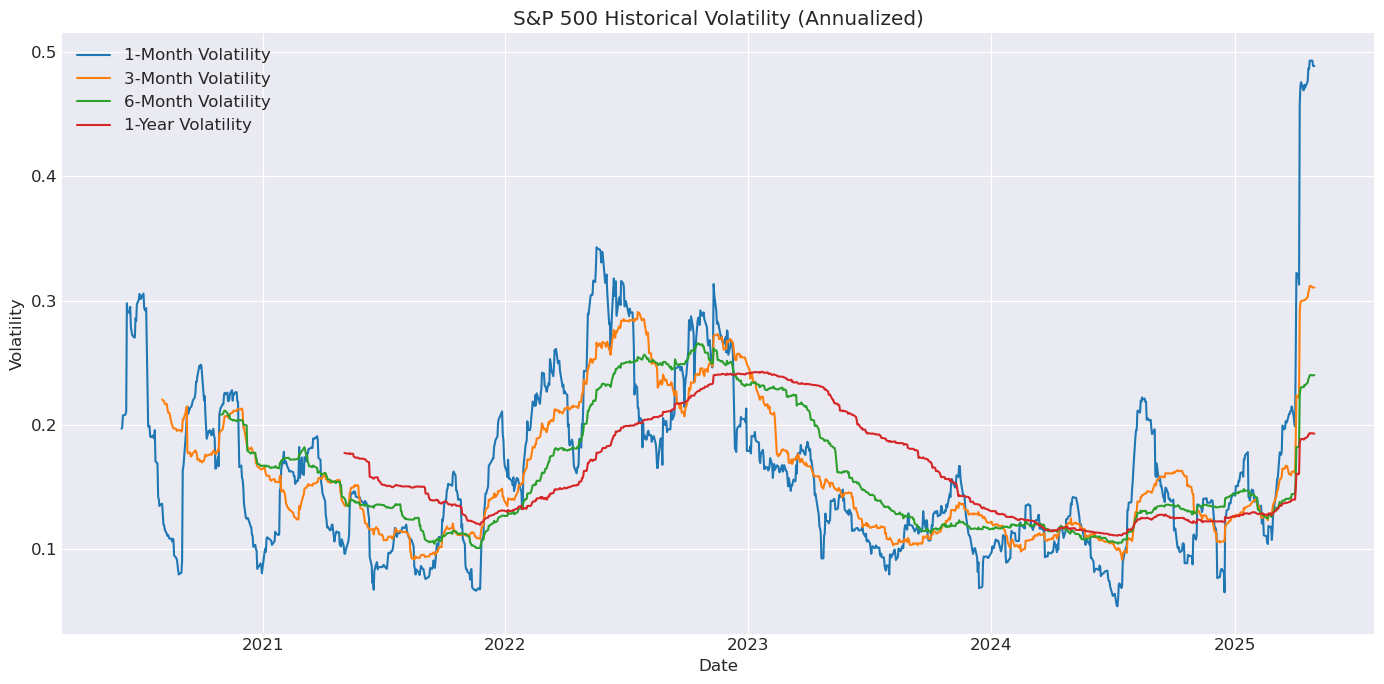

In [6]:
# Calculate historical volatility using different windows
windows = [21, 63, 126, 252]  # 1 month, 3 months, 6 months, 1 year
window_labels = ['1-Month', '3-Month', '6-Month', '1-Year']

for window, label in zip(windows, window_labels):
    sp500[f'Volatility_{label}'] = calculate_historical_volatility(sp500['Log_Returns'], window=window)

# Plot volatility across different time windows
plt.figure(figsize=(14, 7))

for label in window_labels:
    plt.plot(sp500.index, sp500[f'Volatility_{label}'], label=f'{label} Volatility')

plt.title('S&P 500 Historical Volatility (Annualized)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Calculate summary statistics for different volatility windows
vol_stats = pd.DataFrame({
    'Mean': [sp500[f'Volatility_{label}'].mean() for label in window_labels],
    'Median': [sp500[f'Volatility_{label}'].median() for label in window_labels],
    'Min': [sp500[f'Volatility_{label}'].min() for label in window_labels],
    'Max': [sp500[f'Volatility_{label}'].max() for label in window_labels],
    'Std Dev': [sp500[f'Volatility_{label}'].std() for label in window_labels]
}, index=window_labels)

# Format as percentages
vol_stats_pct = vol_stats.applymap(lambda x: f"{x*100:.2f}%")

# Display statistics
print("Historical Volatility Statistics:")
display(vol_stats_pct)

Historical Volatility Statistics:


,Mean,Median,Min,Max,Std Dev
1-Month,16.23%,14.28%,5.42%,49.28%,7.18%
3-Month,16.10%,14.61%,9.15%,31.19%,5.37%
6-Month,16.07%,13.88%,10.09%,26.57%,4.84%
1-Year,16.27%,14.99%,11.09%,24.27%,4.16%


### Analyzing Returns Distribution

Understanding the distribution of returns is important for risk management and for selecting appropriate volatility models.

In [10]:
# Analyze the distribution of returns
log_returns = sp500['Log_Returns'].dropna()

# Calculate descriptive statistics
mean = log_returns.mean()
median = log_returns.median()
std_dev = log_returns.std()
skewness = log_returns.skew()
kurtosis = log_returns.kurtosis()

# Print statistics
print("Log Returns Statistics:")
print(f"Mean: {mean:.6f}")
print(f"Median: {median:.6f}")
print(f"Standard Deviation: {std_dev:.6f}")
print(f"Skewness: {skewness:.6f}")
print(f"Kurtosis: {kurtosis:.6f}")

# Test for normality using Jarque-Bera test
jb_stat, jb_pvalue = stats.jarque_bera(log_returns)
print(f"\nJarque-Bera test:")
print(f"JB statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.10f}")
print(f"Conclusion: {'Normal' if jb_pvalue > 0.05 else 'Non-normal'} distribution")

Log Returns Statistics:
Mean: 0.000541
Median: 0.000907
Standard Deviation: 0.011245
Skewness: -0.187294
Kurtosis: 5.722767

Jarque-Bera test:
JB statistic: 1703.4249
p-value: 0.0000000000
Conclusion: Non-normal distribution


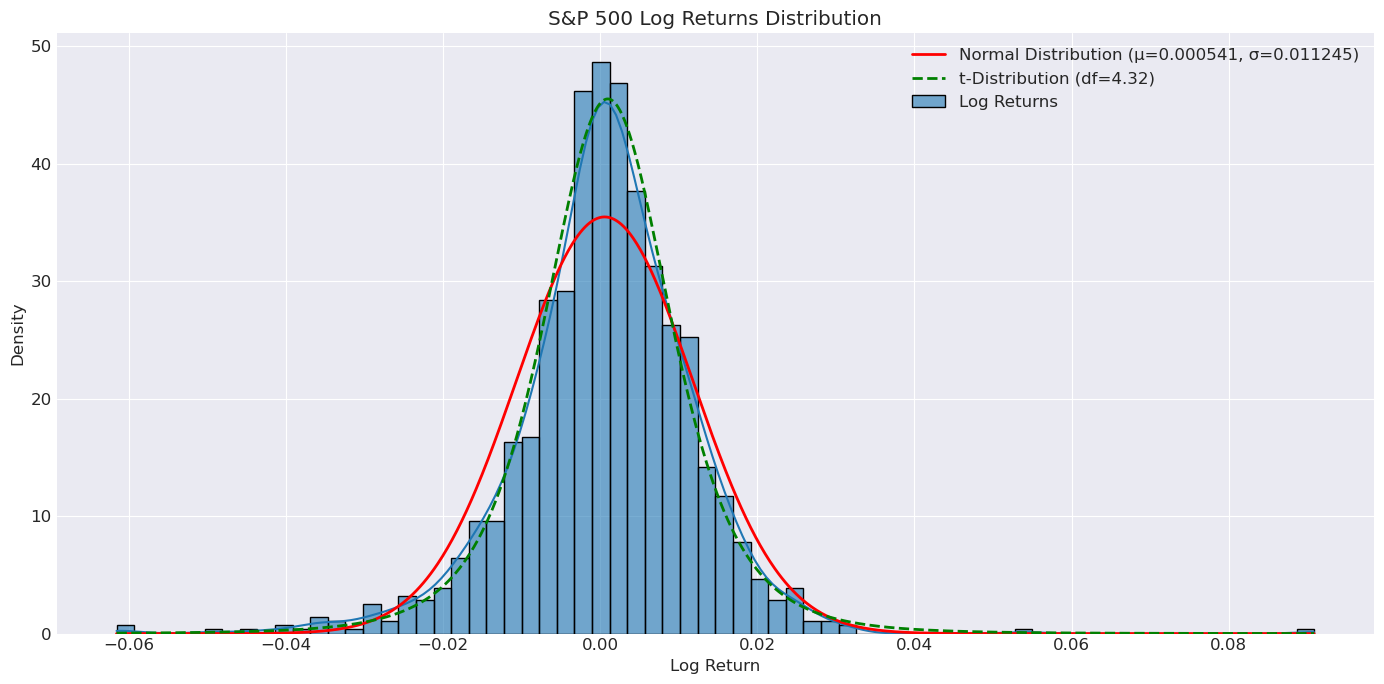

In [11]:
# Plot the distribution of log returns with normal and t-distribution fits
plt.figure(figsize=(14, 7))

# Histogram of log returns
sns.histplot(log_returns, kde=True, stat="density", alpha=0.6, label="Log Returns")

# Fit normal distribution
x = np.linspace(log_returns.min(), log_returns.max(), 1000)
normal_pdf = stats.norm.pdf(x, mean, std_dev)
plt.plot(x, normal_pdf, 'r-', linewidth=2, label=f"Normal Distribution (μ={mean:.6f}, σ={std_dev:.6f})")

# Fit t-distribution
df, loc, scale = stats.t.fit(log_returns)
t_pdf = stats.t.pdf(x, df, loc, scale)
plt.plot(x, t_pdf, 'g--', linewidth=2, label=f"t-Distribution (df={df:.2f})")

plt.title('S&P 500 Log Returns Distribution')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

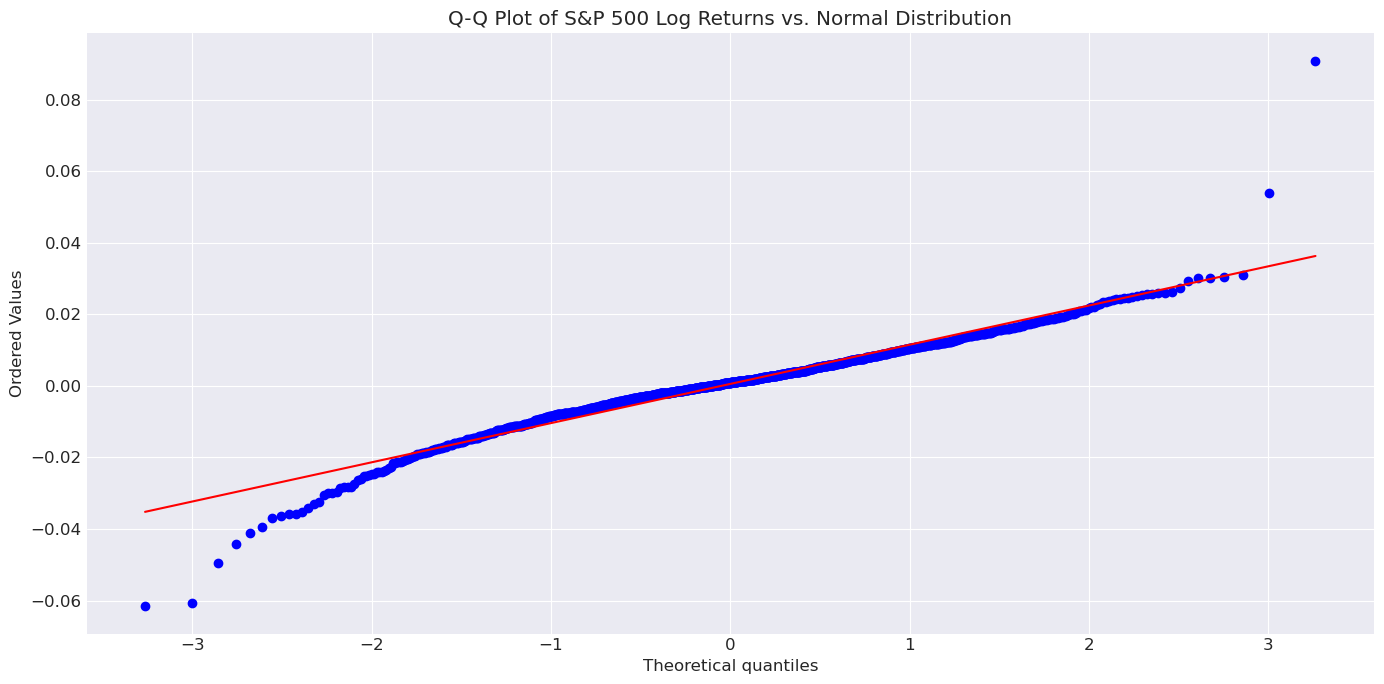

In [12]:
# QQ plot to compare log returns to normal distribution
plt.figure(figsize=(14, 7))
stats.probplot(log_returns, plot=plt)
plt.title("Q-Q Plot of S&P 500 Log Returns vs. Normal Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

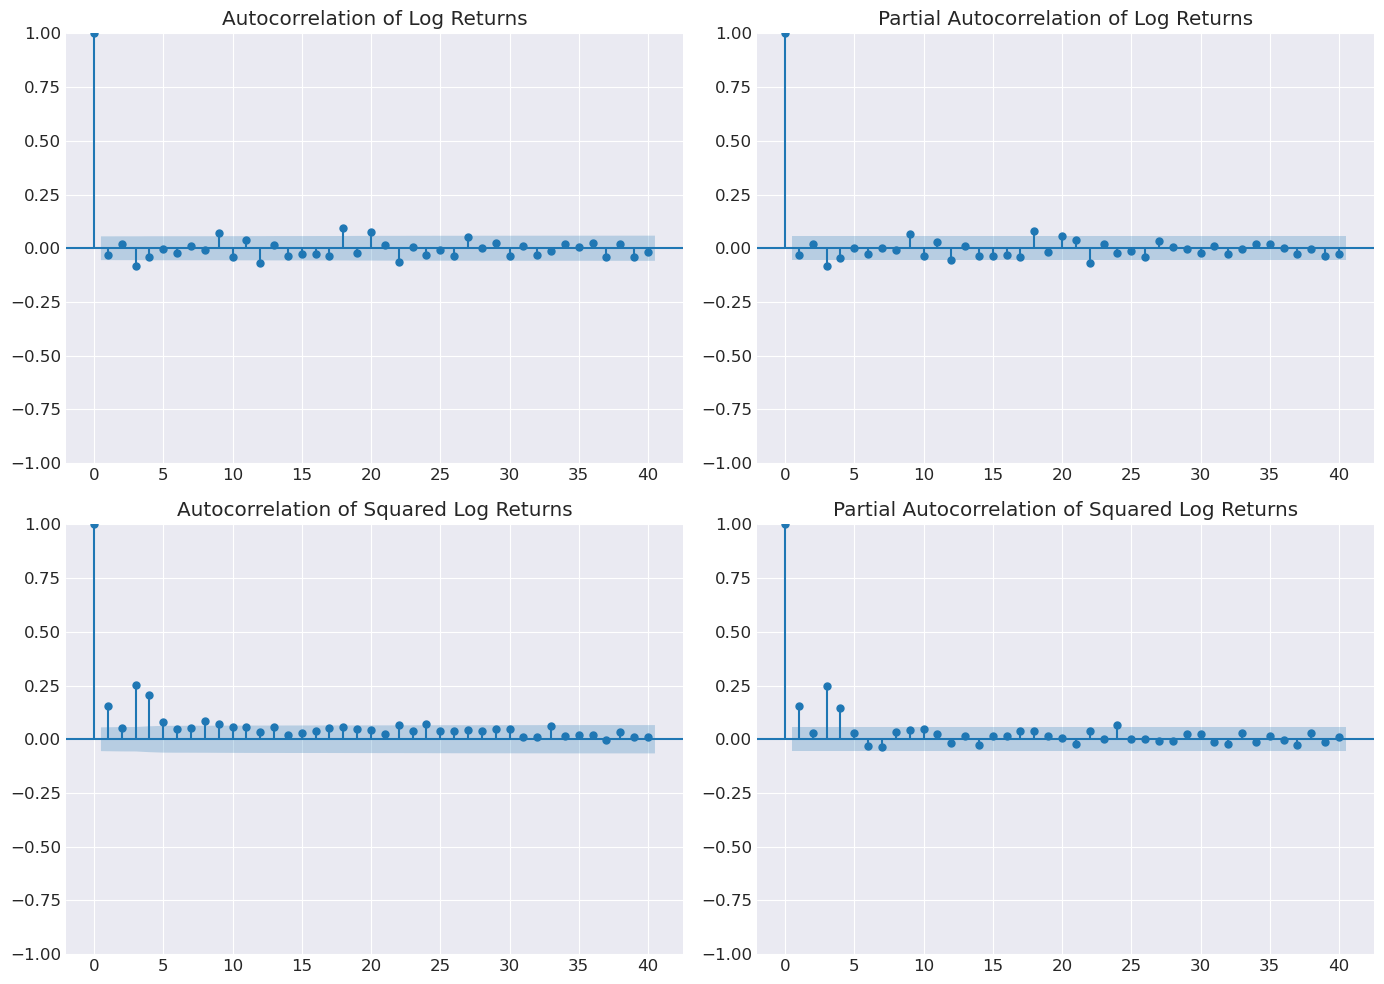

In [13]:
# Check for autocorrelation in returns and squared returns (volatility clustering)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ACF of returns
plot_acf(log_returns, lags=40, ax=axs[0, 0], alpha=0.05)
axs[0, 0].set_title('Autocorrelation of Log Returns')

# PACF of returns
plot_pacf(log_returns, lags=40, ax=axs[0, 1], alpha=0.05)
axs[0, 1].set_title('Partial Autocorrelation of Log Returns')

# ACF of squared returns (volatility clustering)
plot_acf(log_returns**2, lags=40, ax=axs[1, 0], alpha=0.05)
axs[1, 0].set_title('Autocorrelation of Squared Log Returns')

# PACF of squared returns
plot_pacf(log_returns**2, lags=40, ax=axs[1, 1], alpha=0.05)
axs[1, 1].set_title('Partial Autocorrelation of Squared Log Returns')

plt.tight_layout()
plt.show()

## 2. GARCH Models for Volatility Forecasting

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models are designed to handle time-varying volatility and volatility clustering, which are common in financial time series.

In [14]:
# Fit a basic GARCH(1,1) model
garch_model = arch_model(log_returns.dropna() * 100, vol='GARCH', p=1, q=1, mean='Zero')
garch_results = garch_model.fit(disp='off')

# Print model summary
print(garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -1798.95
Distribution:                  Normal   AIC:                           3603.91
Method:            Maximum Likelihood   BIC:                           3619.31
                                        No. Observations:                 1255
Date:                Fri, May 02 2025   Df Residuals:                     1255
Time:                        08:41:21   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0334  1.851e-02      1.805  7.111e-02 

<Figure size 1400x700 with 0 Axes>

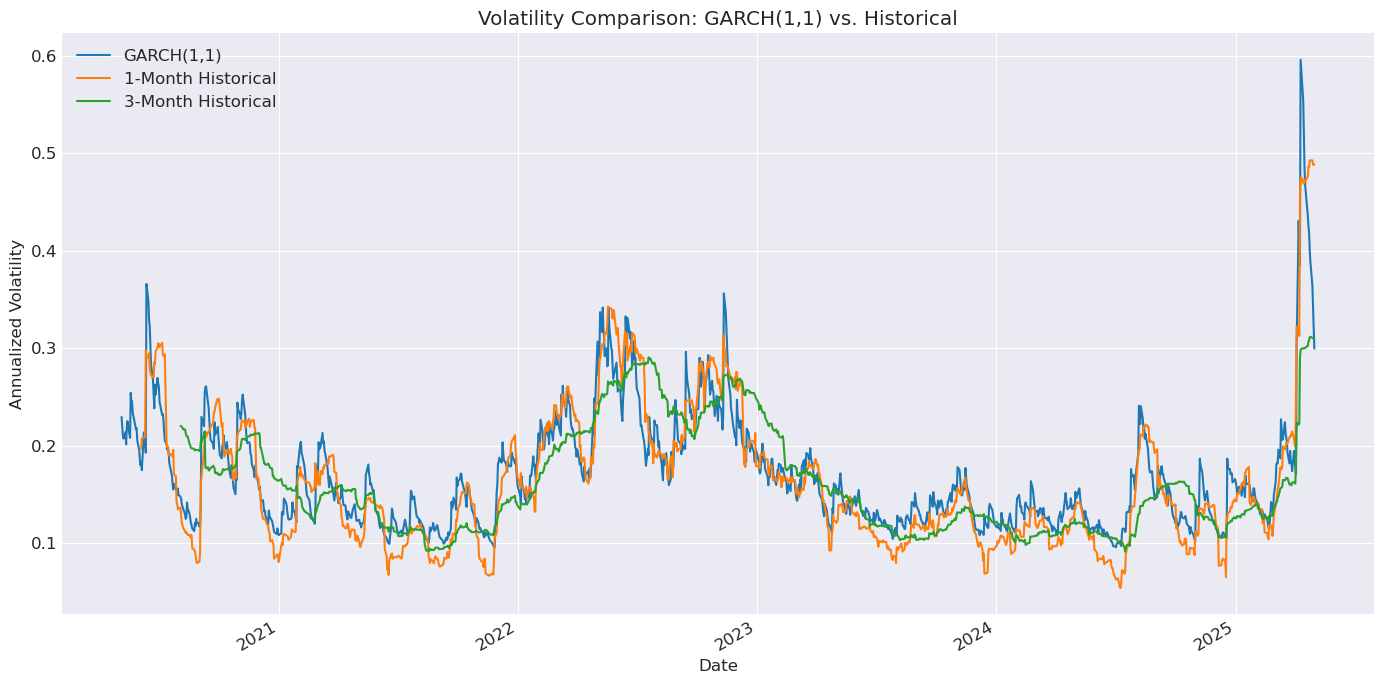

In [15]:
# Plot the GARCH volatility estimate against historical volatility
# Convert GARCH conditional volatility to annualized terms
garch_vol = garch_results.conditional_volatility / 100 * np.sqrt(252)

# Create a DataFrame for comparison
vol_comparison = pd.DataFrame({
    'GARCH(1,1)': garch_vol,
    '1-Month Historical': sp500['Volatility_1-Month'].iloc[1:],
    '3-Month Historical': sp500['Volatility_3-Month'].iloc[1:]
})

# Plot the comparison
plt.figure(figsize=(14, 7))
vol_comparison.plot(figsize=(14, 7))
plt.title('Volatility Comparison: GARCH(1,1) vs. Historical')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Test different GARCH models
models = {
    'GARCH(1,1)': arch_model(log_returns.dropna() * 100, vol='GARCH', p=1, q=1, mean='Zero'),
    'GARCH(1,2)': arch_model(log_returns.dropna() * 100, vol='GARCH', p=1, q=2, mean='Zero'),
    'GARCH(2,1)': arch_model(log_returns.dropna() * 100, vol='GARCH', p=2, q=1, mean='Zero'),
    'EGARCH(1,1)': arch_model(log_returns.dropna() * 100, vol='EGARCH', p=1, q=1, mean='Zero'),
    'GJR-GARCH(1,1)': arch_model(log_returns.dropna() * 100, vol='GARCH', p=1, q=1, o=1, mean='Zero')
}

# Fit each model and store results
results = {}
fit_metrics = []

for name, model in models.items():
    print(f"Fitting {name}...")
    fit = model.fit(disp='off')
    results[name] = fit
    
    # Store metrics
    fit_metrics.append({
        'Model': name,
        'Log-Likelihood': fit.loglikelihood,
        'AIC': fit.aic,
        'BIC': fit.bic
    })

# Create DataFrame of metrics
metrics_df = pd.DataFrame(fit_metrics).set_index('Model')
metrics_df = metrics_df.sort_values('AIC')

# Display metrics
print("\nModel Comparison:")
display(metrics_df)

Fitting GARCH(1,1)...
Fitting GARCH(1,2)...
Fitting GARCH(2,1)...
Fitting EGARCH(1,1)...
Fitting GJR-GARCH(1,1)...

Model Comparison:


,Log-Likelihood,AIC,BIC
Model,,,
"GJR-GARCH(1,1)",-1783.188362,3574.376725,3594.916288
"GARCH(1,1)",-1798.953883,3603.907767,3619.312439
"GARCH(2,1)",-1798.891998,3605.783996,3626.323560
"GARCH(1,2)",-1798.953884,3605.907768,3626.447331
"EGARCH(1,1)",-1803.570411,3613.140823,3628.545495


In [17]:
# Select the best model (lowest AIC)
best_model_name = metrics_df.index[0]
best_model = results[best_model_name]

print(f"Best model: {best_model_name}")
print("\nModel summary:")
print(best_model.summary())

Best model: GJR-GARCH(1,1)

Model summary:
                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                  GJR-GARCH   Log-Likelihood:               -1783.19
Distribution:                  Normal   AIC:                           3574.38
Method:            Maximum Likelihood   BIC:                           3594.92
                                        No. Observations:                 1255
Date:                Fri, May 02 2025   Df Residuals:                     1255
Time:                        08:41:22   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega       

<Figure size 1400x700 with 0 Axes>

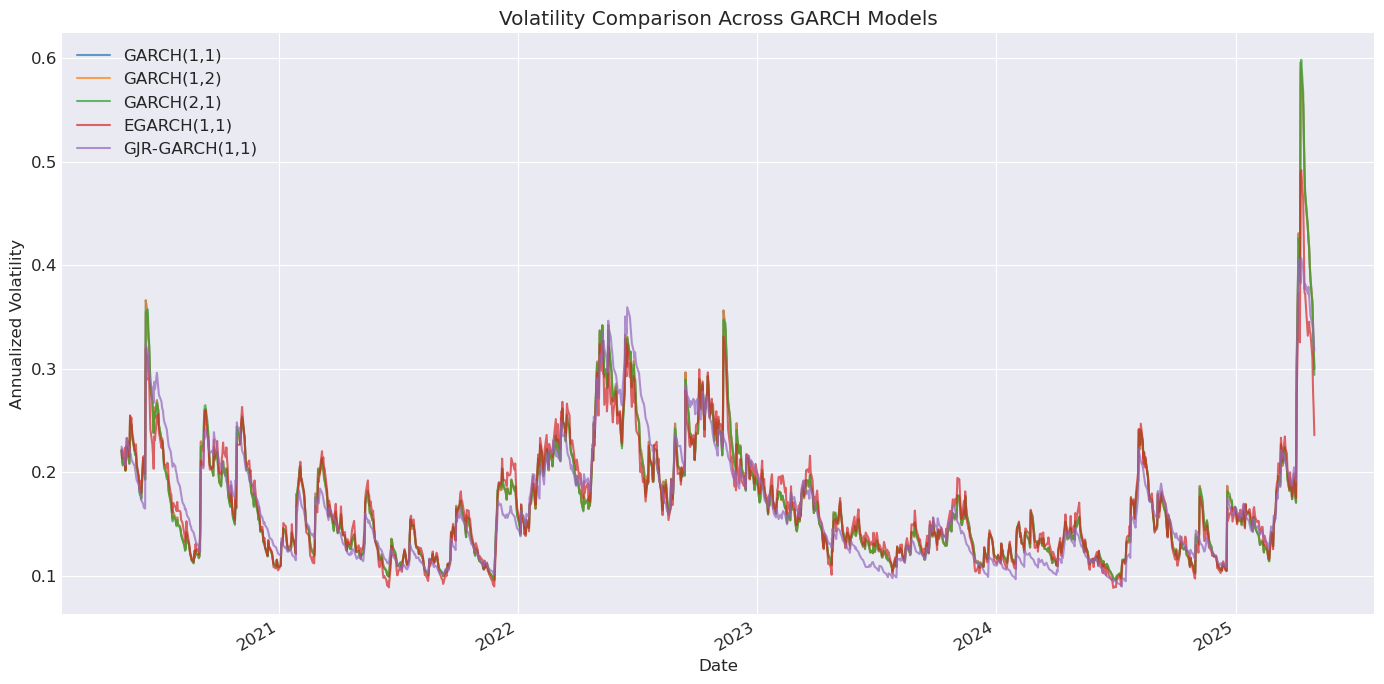

In [18]:
# Compare volatility forecasts from different models
volatility_forecasts = pd.DataFrame(index=log_returns.index[1:])

for name, result in results.items():
    volatility_forecasts[name] = result.conditional_volatility / 100 * np.sqrt(252)

# Plot comparison
plt.figure(figsize=(14, 7))
volatility_forecasts.plot(figsize=(14, 7), alpha=0.7)
plt.title('Volatility Comparison Across GARCH Models')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Forecasting Future Volatility

One of the main advantages of GARCH models is their ability to forecast future volatility.

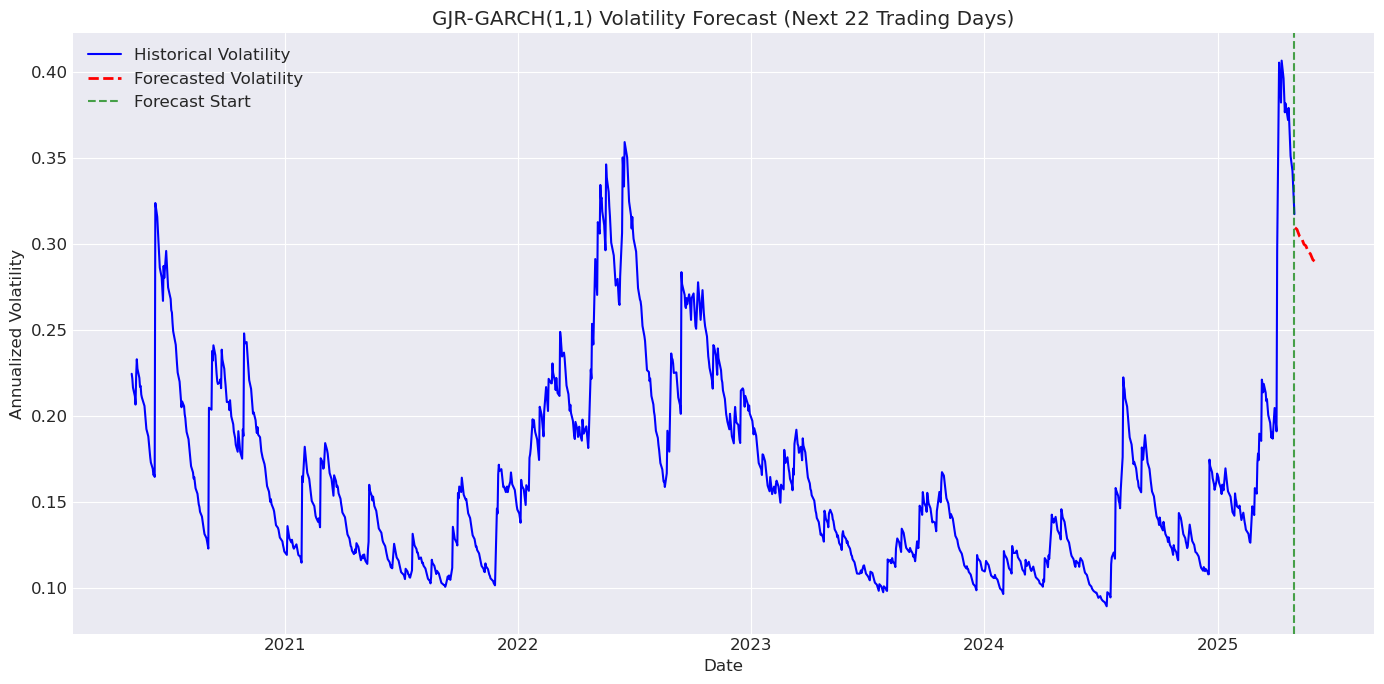

In [19]:
# Forecast volatility using the best model
horizon = 22  # approximately one month
forecast = best_model.forecast(horizon=horizon)

# Extract the volatility forecast
vol_forecast = np.sqrt(forecast.variance.iloc[-1]) / 100 * np.sqrt(252)

# Plot forecasted volatility
plt.figure(figsize=(14, 7))

# Plot historical volatility from the model
plt.plot(volatility_forecasts.index, volatility_forecasts[best_model_name], 'b-', label='Historical Volatility')

# Create forecast date range
last_date = volatility_forecasts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon, freq='B')

# Plot forecasted volatility
plt.plot(forecast_dates, vol_forecast, 'r--', linewidth=2, label='Forecasted Volatility')

# Add a vertical line to mark the forecast start
plt.axvline(x=last_date, color='green', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title(f'{best_model_name} Volatility Forecast (Next {horizon} Trading Days)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Display the detailed forecast
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted Volatility (Annualized)': vol_forecast
})

# Format volatility as percentages
forecast_df['Forecasted Volatility (%)'] = forecast_df['Forecasted Volatility (Annualized)'].apply(lambda x: f"{x*100:.2f}%")

print(f"{best_model_name} Volatility Forecast for the Next {horizon} Trading Days:")
display(forecast_df[['Date', 'Forecasted Volatility (%)']])

GJR-GARCH(1,1) Volatility Forecast for the Next 22 Trading Days:


,Date,Forecasted Volatility (%)
h.01,2025-05-02,30.96%
h.02,2025-05-05,30.87%
h.03,2025-05-06,30.77%
h.04,2025-05-07,30.67%
h.05,2025-05-08,30.57%
h.06,2025-05-09,30.47%
h.07,2025-05-12,30.38%
h.08,2025-05-13,30.28%
h.09,2025-05-14,30.19%
h.10,2025-05-15,30.09%


## 3. Identifying Volatility Regimes

Markets often exhibit different volatility regimes over time, from low volatility periods to high volatility crises. We can use techniques like Gaussian Mixture Models to identify these regimes.

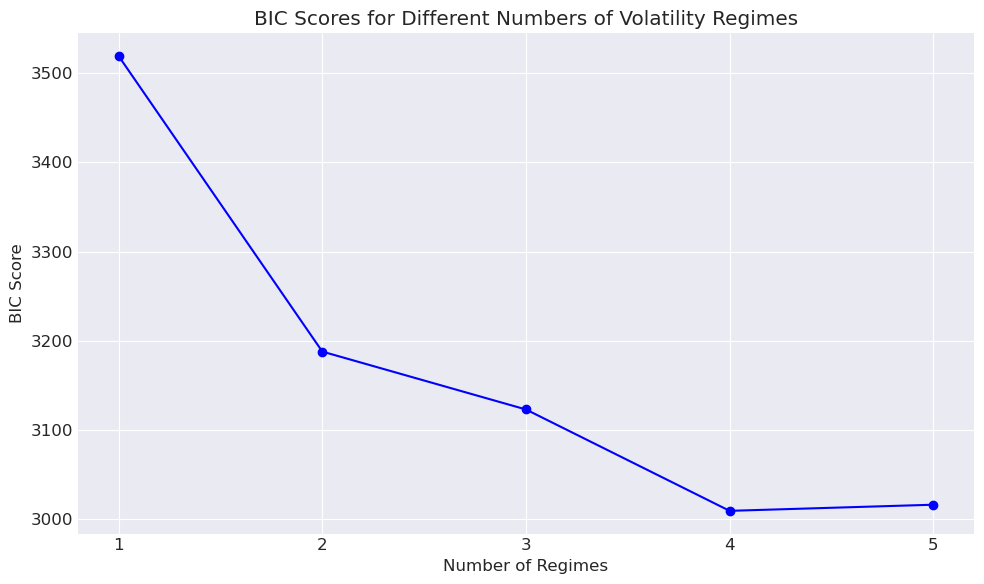

Optimal number of volatility regimes: 4


In [21]:
# Prepare data for regime detection (1-month rolling volatility)
volatility_series = sp500['Volatility_1-Month'].dropna().reset_index()
volatility_series.columns = ['Date', 'Volatility']

# Scale the data for GMM
scaler = StandardScaler()
volatility_scaled = scaler.fit_transform(volatility_series[['Volatility']])

# Try different numbers of regimes (BIC to select optimal number)
n_components_range = range(1, 6)
bic_scores = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(volatility_scaled)
    bic_scores.append(gmm.bic(volatility_scaled))

# Plot BIC scores to determine optimal number of regimes
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, 'bo-')
plt.title('BIC Scores for Different Numbers of Volatility Regimes')
plt.xlabel('Number of Regimes')
plt.ylabel('BIC Score')
plt.grid(True)
plt.xticks(n_components_range)
plt.tight_layout()
plt.show()

# Get optimal number of regimes (lowest BIC)
optimal_n_components = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of volatility regimes: {optimal_n_components}")

In [22]:
# Fit GMM with optimal number of components
gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
gmm.fit(volatility_scaled)

# Predict regimes
regimes = gmm.predict(volatility_scaled)
volatility_series['Regime'] = regimes

# Get mean volatility for each regime
regime_stats = volatility_series.groupby('Regime')['Volatility'].agg(['mean', 'std', 'count'])
regime_stats = regime_stats.sort_values('mean')

# Rename regimes from lowest to highest volatility
regime_map = {old_label: i for i, old_label in enumerate(regime_stats.index)}
volatility_series['Regime'] = volatility_series['Regime'].map(regime_map)

# Update regime stats
regime_stats = volatility_series.groupby('Regime')['Volatility'].agg(['mean', 'std', 'count'])

# Convert to percentage
regime_stats['mean'] = regime_stats['mean'] * 100
regime_stats['std'] = regime_stats['std'] * 100

# Give meaningful names to the regimes
regime_names = ['Low Volatility', 'Normal Volatility', 'High Volatility'] if optimal_n_components == 3 else \
              ['Very Low Volatility', 'Low Volatility', 'Moderate Volatility', 'High Volatility', 'Crisis'] if optimal_n_components == 5 else \
              [f'Regime {i}' for i in range(optimal_n_components)]

regime_stats.index = regime_names[:len(regime_stats)]

# Display regime statistics
print("Volatility Regime Statistics:")
display(pd.DataFrame({
    'Mean Volatility': [f"{m:.2f}%" for m in regime_stats['mean']],
    'Std Dev': [f"{s:.2f}%" for s in regime_stats['std']],
    'Count': regime_stats['count'],
    'Percentage': [f"{c/sum(regime_stats['count'])*100:.2f}%" for c in regime_stats['count']]
}))

Volatility Regime Statistics:


,Mean Volatility,Std Dev,Count,Percentage
Regime 0,11.17%,2.15%,659,53.36%
Regime 1,18.65%,2.34%,403,32.63%
Regime 2,28.02%,2.71%,157,12.71%
Regime 3,48.01%,1.08%,16,1.30%


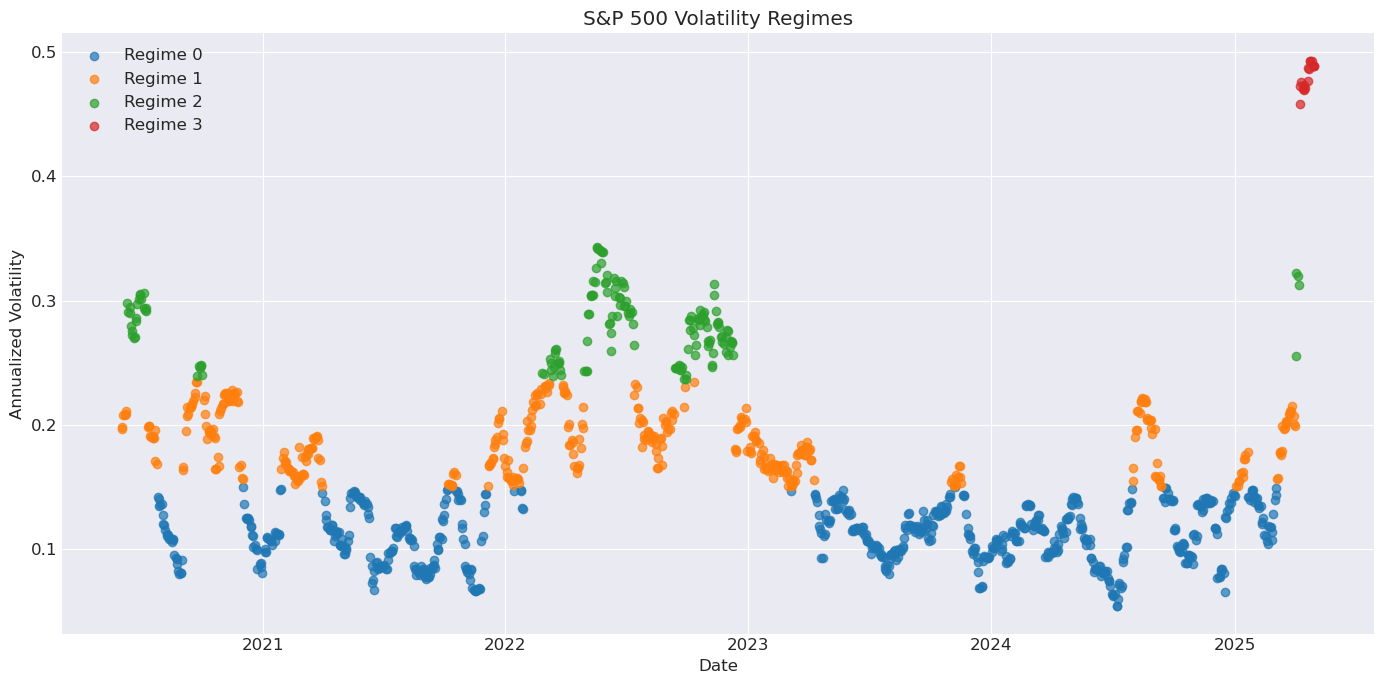

In [23]:
# Plot volatility with regimes
plt.figure(figsize=(14, 7))

# Create a colormap for the regimes
colors = ['g', 'b', 'r'] if optimal_n_components == 3 else ['g', 'c', 'b', 'y', 'r'] if optimal_n_components == 5 else None

# Plot each regime
for i, regime_name in enumerate(regime_names[:len(regime_stats)]):
    regime_data = volatility_series[volatility_series['Regime'] == i]
    plt.scatter(regime_data['Date'], regime_data['Volatility'], 
                color=colors[i] if colors else None, alpha=0.7, label=regime_name)

plt.title('S&P 500 Volatility Regimes')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

New flattened columns: ['Adj Close_^GSPC', 'Close_^GSPC', 'High_^GSPC', 'Low_^GSPC', 'Open_^GSPC', 'Volume_^GSPC', 'Returns', 'Log_Returns', 'Volatility_1-Month', 'Volatility_3-Month', 'Volatility_6-Month', 'Volatility_1-Year']


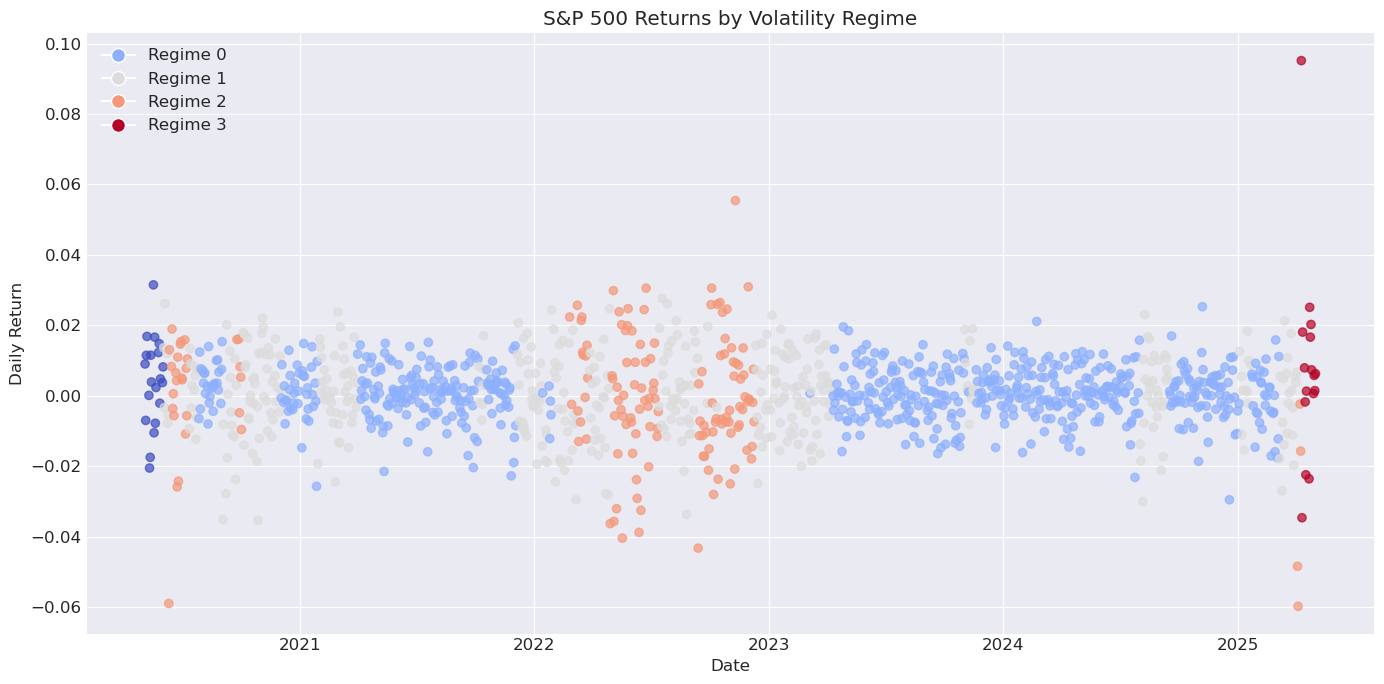

In [43]:
# Convert the MultiIndex columns to a flat structure
sp500_flat = sp500.copy()
sp500_flat.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in sp500_flat.columns]

print("New flattened columns:", sp500_flat.columns.tolist())

# Now merge should work with the flattened column structure
sp500_with_regimes = pd.merge(
    sp500_flat.reset_index() if sp500_flat.index.name is not None else sp500_flat,
    volatility_series_flat[['Date', 'Regime']],
    on='Date',
    how='left'
)

# Set Date as index if desired
sp500_with_regimes = sp500_with_regimes.set_index('Date')

# Plot S&P 500 returns in different regimes
plt.figure(figsize=(14, 7))

scatter = plt.scatter(sp500_with_regimes.index, sp500_with_regimes['Returns'],
            c=sp500_with_regimes['Regime'].fillna(-1), cmap='coolwarm', alpha=0.7)

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(i)), 
                             label=regime_names[i] if i < len(regime_names) else 'Unknown', markersize=10) 
                  for i in range(optimal_n_components)]

plt.legend(handles=legend_elements)
plt.title('S&P 500 Returns by Volatility Regime')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.tight_layout()
plt.show()

### Performance in Different Volatility Regimes

Let's analyze how the S&P 500 performs in different volatility regimes.

In [44]:
# Calculate performance metrics by regime
def calculate_regime_performance(df, regime_column='Regime', returns_column='Returns'):
    """
    Calculate performance metrics for each regime
    """
    # Prepare data
    data = df.dropna(subset=[regime_column, returns_column]).copy()
    regimes = data[regime_column].unique()
    regimes.sort()
    
    performance = []
    
    for regime in regimes:
        regime_data = data[data[regime_column] == regime]
        regime_returns = regime_data[returns_column]
        
        # Calculate metrics
        avg_return = regime_returns.mean()
        annualized_return = (1 + avg_return) ** 252 - 1
        volatility = regime_returns.std() * np.sqrt(252)
        sharpe = annualized_return / volatility if volatility > 0 else 0
        skewness = regime_returns.skew()
        positive_days = (regime_returns > 0).mean() * 100
        
        regime_index = regime_names[int(regime)] if int(regime) < len(regime_names) else f'Regime {int(regime)}'
        
        performance.append({
            'Regime': regime_index,
            'Days': len(regime_returns),
            'Avg Daily Return': avg_return,
            'Annualized Return': annualized_return,
            'Annualized Volatility': volatility,
            'Sharpe Ratio': sharpe,
            'Skewness': skewness,
            'Positive Days %': positive_days
        })
    
    return pd.DataFrame(performance)

In [45]:
# Calculate performance by regime
regime_performance = calculate_regime_performance(sp500_with_regimes)

# Format results
formatted_performance = regime_performance.copy()
formatted_performance['Avg Daily Return'] = formatted_performance['Avg Daily Return'].apply(lambda x: f"{x*100:.4f}%")
formatted_performance['Annualized Return'] = formatted_performance['Annualized Return'].apply(lambda x: f"{x*100:.2f}%")
formatted_performance['Annualized Volatility'] = formatted_performance['Annualized Volatility'].apply(lambda x: f"{x*100:.2f}%")
formatted_performance['Sharpe Ratio'] = formatted_performance['Sharpe Ratio'].apply(lambda x: f"{x:.2f}")
formatted_performance['Positive Days %'] = formatted_performance['Positive Days %'].apply(lambda x: f"{x:.2f}%")

# Display results
print("S&P 500 Performance by Volatility Regime:")
display(formatted_performance)

S&P 500 Performance by Volatility Regime:


,Regime,Days,Avg Daily Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Skewness,Positive Days %
0,Regime 0,659,0.0730%,20.19%,11.62%,1.74,-0.390942,56.30%
1,Regime 1,403,0.0542%,14.64%,18.75%,0.78,-0.290628,52.11%
2,Regime 2,157,-0.0939%,-21.08%,28.58%,-0.74,-0.456521,45.86%
3,Regime 3,16,0.7740%,597.94%,45.26%,13.21,1.778758,75.00%


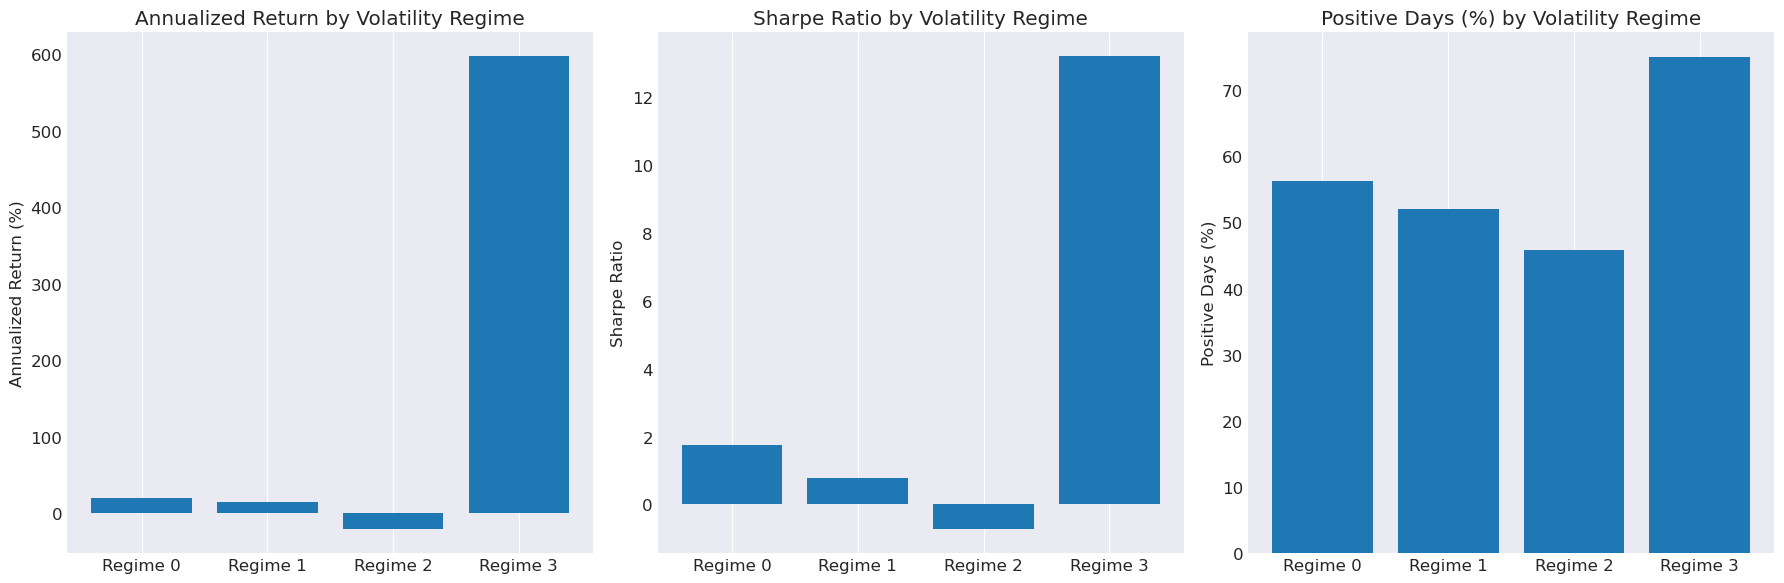

In [46]:
# Visualize key performance metrics by regime
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Annualized return by regime
axs[0].bar(regime_performance['Regime'], regime_performance['Annualized Return'] * 100, 
           color=['g', 'b', 'r'] if len(regime_performance) == 3 else None)
axs[0].set_title('Annualized Return by Volatility Regime')
axs[0].set_ylabel('Annualized Return (%)')
axs[0].grid(axis='y')

# Sharpe ratio by regime
axs[1].bar(regime_performance['Regime'], regime_performance['Sharpe Ratio'],
           color=['g', 'b', 'r'] if len(regime_performance) == 3 else None)
axs[1].set_title('Sharpe Ratio by Volatility Regime')
axs[1].set_ylabel('Sharpe Ratio')
axs[1].grid(axis='y')

# Positive days % by regime
axs[2].bar(regime_performance['Regime'], regime_performance['Positive Days %'],
           color=['g', 'b', 'r'] if len(regime_performance) == 3 else None)
axs[2].set_title('Positive Days (%) by Volatility Regime')
axs[2].set_ylabel('Positive Days (%)')
axs[2].grid(axis='y')

plt.tight_layout()
plt.show()

## 4. VIX Analysis: Implied Volatility Index

The VIX (CBOE Volatility Index) is a popular measure of the stock market's expected volatility based on S&P 500 index options. Let's analyze how it relates to S&P 500 returns and historical volatility.

In [47]:
# Download VIX data
vix = yf.download('^VIX', period='5y')

# Merge with S&P 500 data
sp500_vix = pd.merge(sp500[['Close', 'Returns', 'Volatility_1-Month']], 
                      vix[['Close']], 
                      left_index=True, 
                      right_index=True, 
                      how='inner',
                      suffixes=('_SP500', '_VIX'))

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price             Close   Returns Volatility_1-Month      Close
Ticker            ^GSPC                                    ^VIX
Date                                                           
2020-05-04  2842.739990       NaN                NaN  35.970001
2020-05-05  2868.439941  0.009041                NaN  33.610001
2020-05-06  2848.419922 -0.006979                NaN  34.119999
2020-05-07  2881.189941  0.011505                NaN  31.440001
2020-05-08  2929.800049  0.016872                NaN  27.980000


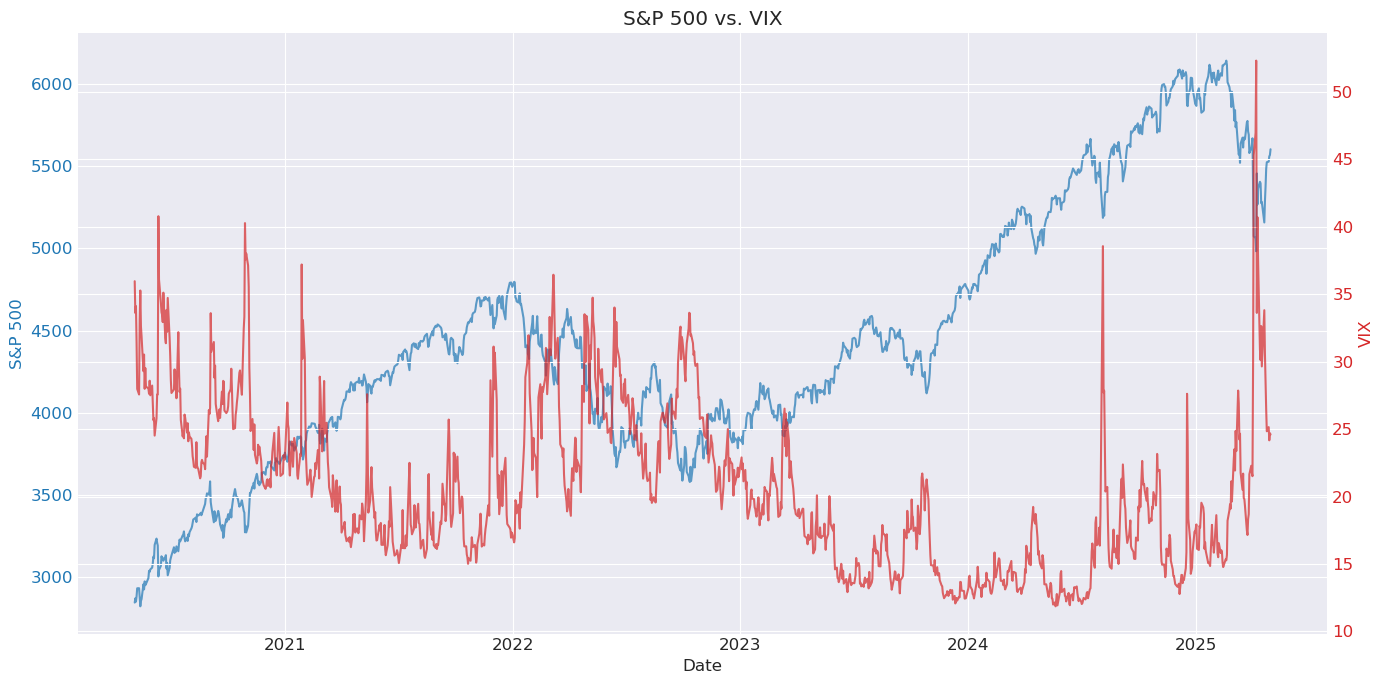

In [54]:
print(sp500_vix.head())
# Plot S&P 500 and VIX
fig, ax1 = plt.subplots(figsize=(14, 7))

# S&P 500
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('S&P 500', color=color)
ax1.plot(sp500_vix.index, sp500_vix['Close']['^GSPC'], color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# VIX on secondary axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('VIX', color=color)
ax2.plot(sp500_vix.index, sp500_vix['Close']['^VIX'], color=color, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('S&P 500 vs. VIX')
plt.grid(True)
fig.tight_layout()
plt.show()

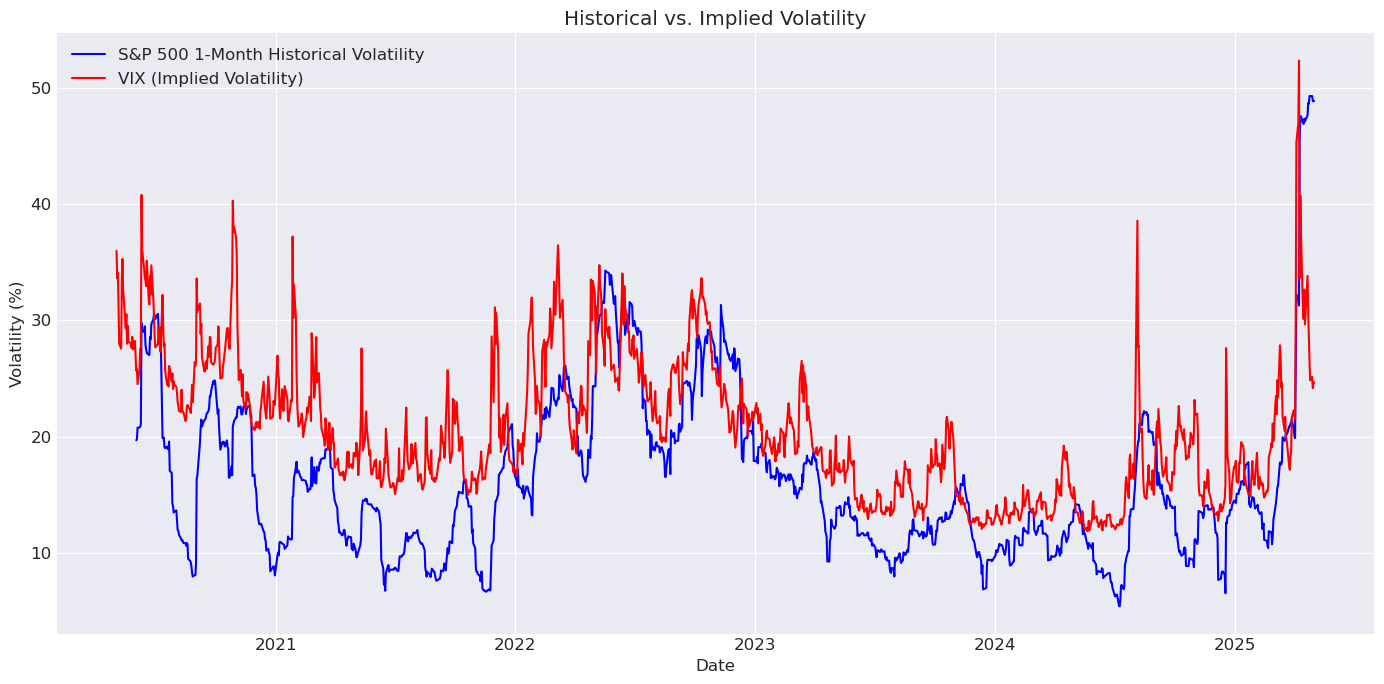

In [56]:
# Compare VIX to 1-month historical volatility
plt.figure(figsize=(14, 7))
plt.plot(sp500_vix.index, sp500_vix['Volatility_1-Month'] * 100, 'b-', label='S&P 500 1-Month Historical Volatility')
plt.plot(sp500_vix.index, sp500_vix['Close']['^VIX'], 'r-', label='VIX (Implied Volatility)')
plt.title('Historical vs. Implied Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Correlation Matrix:


Price                       Returns     Close           Volatility_1-Month
Ticker                                  ^GSPC      ^VIX                   
Price              Ticker                                                 
Returns                    1.000000  0.007162 -0.175752           0.010624
Close              ^GSPC   0.007162  1.000000 -0.547625          -0.278286
                   ^VIX   -0.175752 -0.547625  1.000000           0.692863
Volatility_1-Month         0.010624 -0.278286  0.692863           1.000000

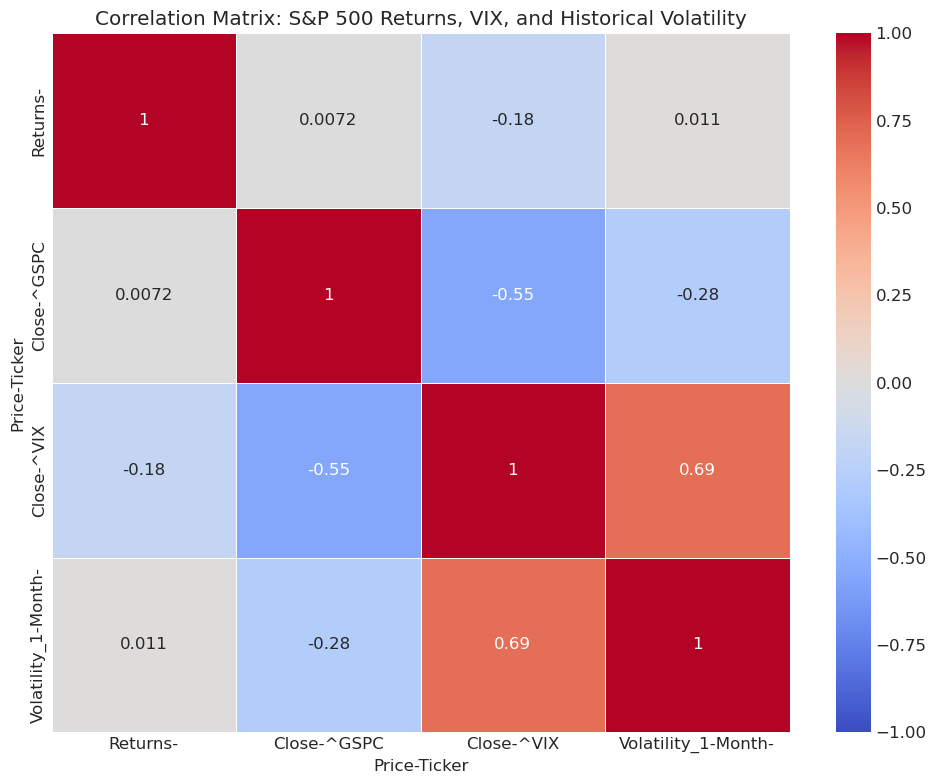

In [62]:
# Calculate the correlation between VIX and S&P 500 returns
corr_matrix = sp500_vix[['Returns', 'Close', 'Volatility_1-Month']].corr()

# Display correlation matrix
print("Correlation Matrix:")
display(corr_matrix)

# Plot correlation matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
plt.title('Correlation Matrix: S&P 500 Returns, VIX, and Historical Volatility')
plt.tight_layout()
plt.show()

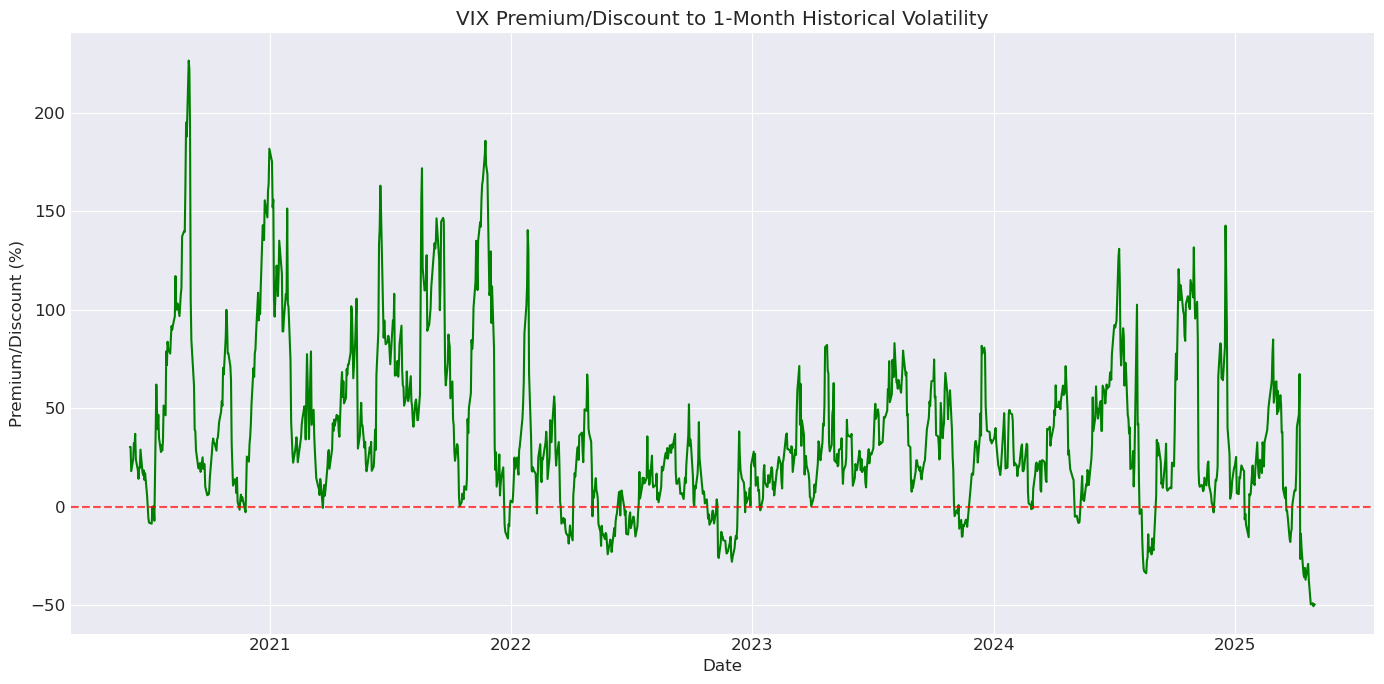

In [64]:
# Analyze the VIX premium/discount to historical volatility
sp500_vix['VIX_Premium'] = sp500_vix['Close']['^VIX'] / (sp500_vix['Volatility_1-Month'] * 100) - 1

# Plot VIX premium/discount
plt.figure(figsize=(14, 7))
plt.plot(sp500_vix.index, sp500_vix['VIX_Premium'] * 100, 'g-')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
plt.title('VIX Premium/Discount to 1-Month Historical Volatility')
plt.xlabel('Date')
plt.ylabel('Premium/Discount (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### VIX as a Trading Signal

Let's explore how VIX levels and relative changes can be used as trading signals for the S&P 500.

In [ ]:
# Add forward returns to analyze how the S&P 500 performs after different VIX events
for days in [1, 5, 10, 21, 63]:  # 1-day, 1-week, 2-week, 1-month, 3-month forward returns
    sp500_vix[f'Forward_Return_{days}d'] = sp500_vix['Close']['^GSPC'].pct_change(periods=days).shift(-days)

# Add VIX changes
sp500_vix['VIX_1d_Change'] = sp500_vix['Close']['^VIX'].pct_change()
sp500_vix['VIX_5d_Change'] = sp500_vix['Close']['^VIX'].pct_change(periods=5)

# Create bins for VIX level and VIX changes
vix_level_bins = [0, 15, 20, 25, 30, 100]  # VIX level bins
vix_level_labels = ['Very Low (<15)', 'Low (15-20)', 'Normal (20-25)', 'High (25-30)', 'Very High (>30)']
sp500_vix['VIX_Level_Category'] = pd.cut(sp500_vix['Close']['^VIX'], bins=vix_level_bins, labels=vix_level_labels)

vix_change_bins = [-1, -0.1, -0.05, 0, 0.05, 0.1, 1]  # VIX 1-day change bins
vix_change_labels = ['Large Drop (<-10%)', 'Moderate Drop (-10% to -5%)', 'Small Drop (-5% to 0%)', 
                      'Small Rise (0% to 5%)', 'Moderate Rise (5% to 10%)', 'Large Rise (>10%)']
sp500_vix['VIX_Change_Category'] = pd.cut(sp500_vix['VIX_1d_Change'], bins=vix_change_bins, labels=vix_change_labels)

In [77]:
# Analyze forward returns by VIX level
# Flatten MultiIndex columns if present
if isinstance(sp500_vix.columns, pd.MultiIndex):
    sp500_vix.columns = [f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col for col in sp500_vix.columns]

# Create VIX level categories
vix_level_bins = [0, 15, 20, 25, 30, 100]  # VIX level bins
vix_level_labels = ['Very Low (<15)', 'Low (15-20)', 'Normal (20-25)', 'High (25-30)', 'Very High (>30)']
sp500_vix['VIX_Level_Category'] = pd.cut(sp500_vix['Close_^VIX'], bins=vix_level_bins, labels=vix_level_labels)

# Analyze forward returns by VIX level
vix_level_performance = sp500_vix.groupby('VIX_Level_Category')[
    ['Forward_Return_1d_', 'Forward_Return_5d_', 'Forward_Return_10d_', 'Forward_Return_21d_']
].mean() * 100

# Add count of days
vix_level_performance['Count'] = sp500_vix.groupby('VIX_Level_Category').size()
vix_level_performance['Percentage'] = vix_level_performance['Count'] / vix_level_performance['Count'].sum() * 100

# Display results
print("\nAverage S&P 500 Forward Returns by VIX Level:")
display(vix_level_performance)


Average S&P 500 Forward Returns by VIX Level:


,Forward_Return_1d_,Forward_Return_5d_,Forward_Return_10d_,Forward_Return_21d_,Count,Percentage
VIX_Level_Category,,,,,,
Very Low (<15),0.044393,0.331804,0.599412,1.164838,237,18.869427
Low (15-20),0.021830,0.020735,0.024848,0.553372,427,33.996815
Normal (20-25),0.051095,0.202283,0.492594,0.511994,311,24.761146
High (25-30),0.057449,0.243472,0.731721,1.641122,180,14.331210
Very High (>30),0.295026,1.705326,2.733899,4.837549,101,8.041401


In [80]:
# Check if VIX_1d_Change exists, if not create it
if 'VIX_1d_Change' not in sp500_vix.columns:
    sp500_vix['VIX_1d_Change'] = sp500_vix['Close_^VIX'].pct_change()

# Create VIX change categories
vix_change_bins = [-1, -0.1, -0.05, 0, 0.05, 0.1, 1]  # VIX 1-day change bins
vix_change_labels = ['Large Drop (<-10%)', 'Moderate Drop (-10% to -5%)', 'Small Drop (-5% to 0%)', 
                     'Small Rise (0% to 5%)', 'Moderate Rise (5% to 10%)', 'Large Rise (>10%)']
sp500_vix['VIX_Change_Category'] = pd.cut(sp500_vix['VIX_1d_Change'], bins=vix_change_bins, labels=vix_change_labels)

# Identify the correct forward return column names
forward_return_columns = [col for col in sp500_vix.columns if col.startswith('Forward_Return_')]
if not forward_return_columns:
    # If no columns match directly, use the columns with trailing underscore as seen in vix_level_performance
    forward_return_columns = ['Forward_Return_1d_', 'Forward_Return_5d_', 'Forward_Return_10d_', 'Forward_Return_21d_']

# Analyze forward returns by VIX change
vix_change_performance = sp500_vix.groupby('VIX_Change_Category')[forward_return_columns].mean() * 100

# Add count of days
vix_change_performance['Count'] = sp500_vix.groupby('VIX_Change_Category').size()
vix_change_performance['Percentage'] = vix_change_performance['Count'] / vix_change_performance['Count'].sum() * 100

# Display results
print("Average S&P 500 Forward Returns by VIX Daily Change:")
display(vix_change_performance)

Average S&P 500 Forward Returns by VIX Daily Change:


,Forward_Return_1d_,Forward_Return_5d_,Forward_Return_10d_,Forward_Return_21d_,Forward_Return_63d_,Count,Percentage
VIX_Change_Category,,,,,,,
Large Drop (<-10%),0.095789,0.361156,1.129767,1.989631,2.849023,57,4.541833
Moderate Drop (-10% to -5%),0.036920,0.205314,0.476818,1.404599,3.655625,191,15.219124
Small Drop (-5% to 0%),0.045290,0.204324,0.402588,0.790205,3.236759,463,36.892430
Small Rise (0% to 5%),0.085331,0.432816,0.595952,1.185700,3.845434,302,24.063745
Moderate Rise (5% to 10%),0.086238,0.482303,0.852145,1.729958,3.690403,137,10.916335
Large Rise (>10%),0.037106,0.120255,0.627098,0.567686,3.451076,105,8.366534


<Figure size 1400x800 with 0 Axes>

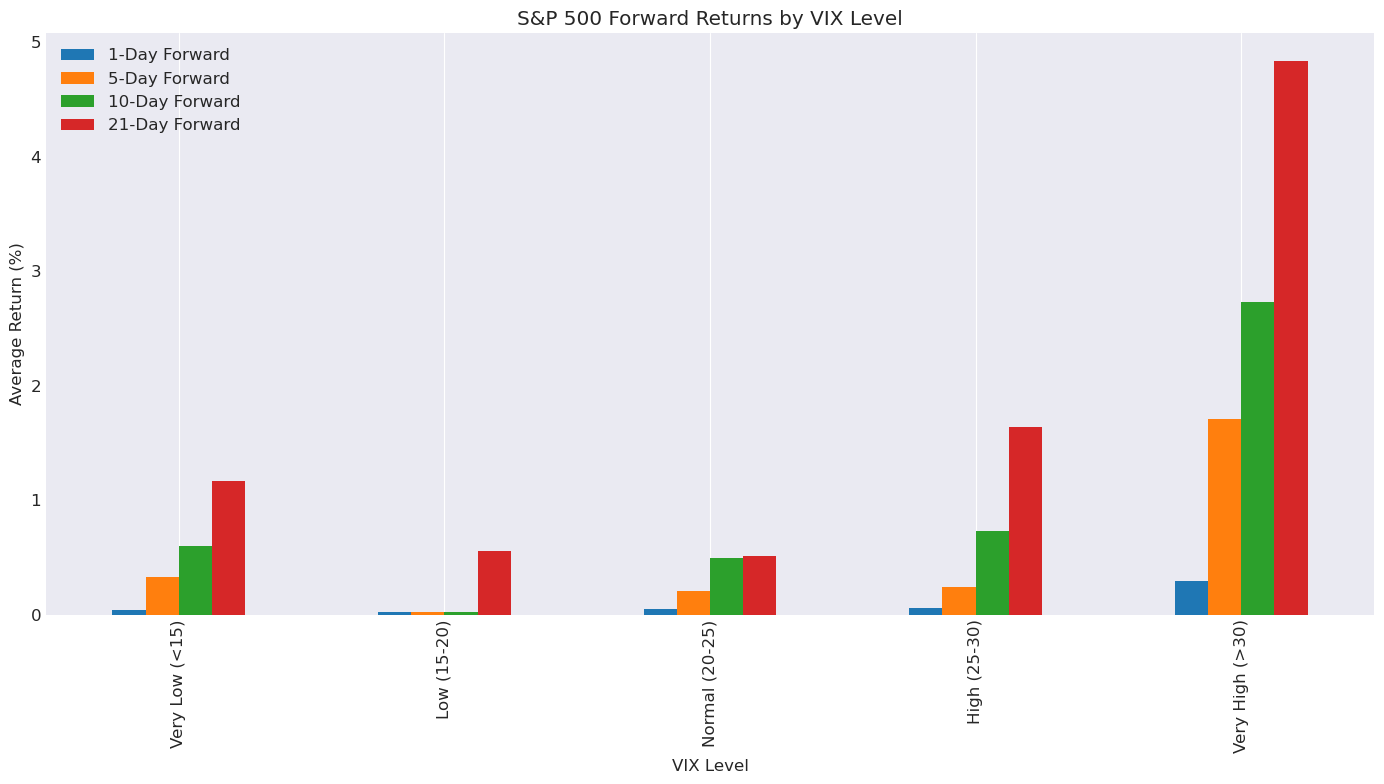

In [82]:
# Visualize forward returns by VIX level
plt.figure(figsize=(14, 8))

vix_level_performance[['Forward_Return_1d_', 'Forward_Return_5d_', 'Forward_Return_10d_', 'Forward_Return_21d_']].plot(
    kind='bar', figsize=(14, 8))

plt.title('S&P 500 Forward Returns by VIX Level')
plt.xlabel('VIX Level')
plt.ylabel('Average Return (%)')
plt.grid(axis='y')
plt.legend(['1-Day Forward', '5-Day Forward', '10-Day Forward', '21-Day Forward'])
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

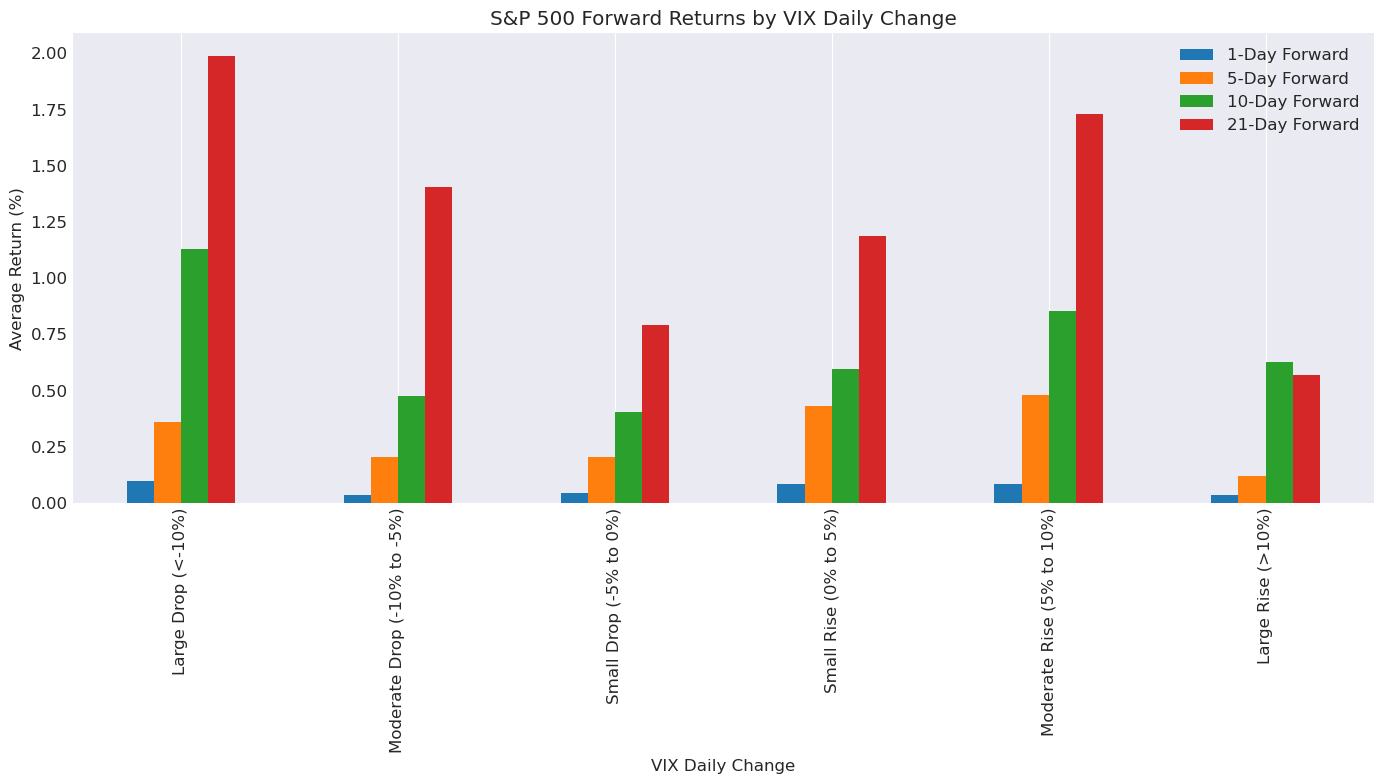

In [84]:
# Visualize forward returns by VIX change
plt.figure(figsize=(14, 8))

vix_change_performance[['Forward_Return_1d_', 'Forward_Return_5d_', 'Forward_Return_10d_', 'Forward_Return_21d_']].plot(
    kind='bar', figsize=(14, 8))

plt.title('S&P 500 Forward Returns by VIX Daily Change')
plt.xlabel('VIX Daily Change')
plt.ylabel('Average Return (%)')
plt.grid(axis='y')
plt.legend(['1-Day Forward', '5-Day Forward', '10-Day Forward', '21-Day Forward'])
plt.tight_layout()
plt.show()

## 5. Volatility-Based Position Sizing and Risk Management

Let's implement a simple volatility-based position sizing strategy for the S&P 500, adjusting exposure based on forecasted volatility.

In [85]:
# Volatility targeting strategy
def volatility_targeting_strategy(returns, volatility, target_volatility=0.10, max_leverage=2.0):
    """
    Implement a volatility targeting strategy
    
    Parameters:
    returns: Series of asset returns
    volatility: Series of volatility forecasts (annualized)
    target_volatility: Target annualized volatility
    max_leverage: Maximum allowed leverage
    
    Returns:
    DataFrame with strategy results
    """
    # Create DataFrame
    strategy = pd.DataFrame({
        'Returns': returns,
        'Volatility': volatility
    })
    
    # Calculate position size (inverse to volatility, scaled to target)
    strategy['Position'] = target_volatility / strategy['Volatility']
    
    # Apply leverage constraint
    strategy['Position'] = strategy['Position'].clip(upper=max_leverage)
    
    # Shift position to avoid look-ahead bias (use yesterday's volatility for today's position)
    strategy['Position'] = strategy['Position'].shift(1)
    
    # Calculate strategy returns
    strategy['Strategy_Returns'] = strategy['Position'] * strategy['Returns']
    
    # Calculate cumulative returns
    strategy['Cumulative_Returns'] = (1 + strategy['Returns']).cumprod() - 1
    strategy['Strategy_Cumulative'] = (1 + strategy['Strategy_Returns']).cumprod() - 1
    
    return strategy

In [87]:
# Use the GARCH volatility for position sizing

# Get returns from sp500 DataFrame (ensure single-level columns)
sp500_returns = pd.DataFrame({
    'Returns': sp500['Returns'] if isinstance(sp500['Returns'], pd.Series) 
               else sp500['Returns'].iloc[:, 0]
})

# Create DataFrame with GARCH volatility
garch_vol_df = pd.DataFrame({
    'Volatility': volatility_forecasts[best_model_name]
})

# Merge the data
vol_strategy_data = pd.merge(
    sp500_returns,
    garch_vol_df,
    left_index=True,
    right_index=True,
    how='inner'
)

# Apply volatility targeting strategy with 10% target
volatility_strategy = volatility_targeting_strategy(
    vol_strategy_data['Returns'],
    vol_strategy_data['Volatility'],
    target_volatility=0.10,
    max_leverage=2.0
)

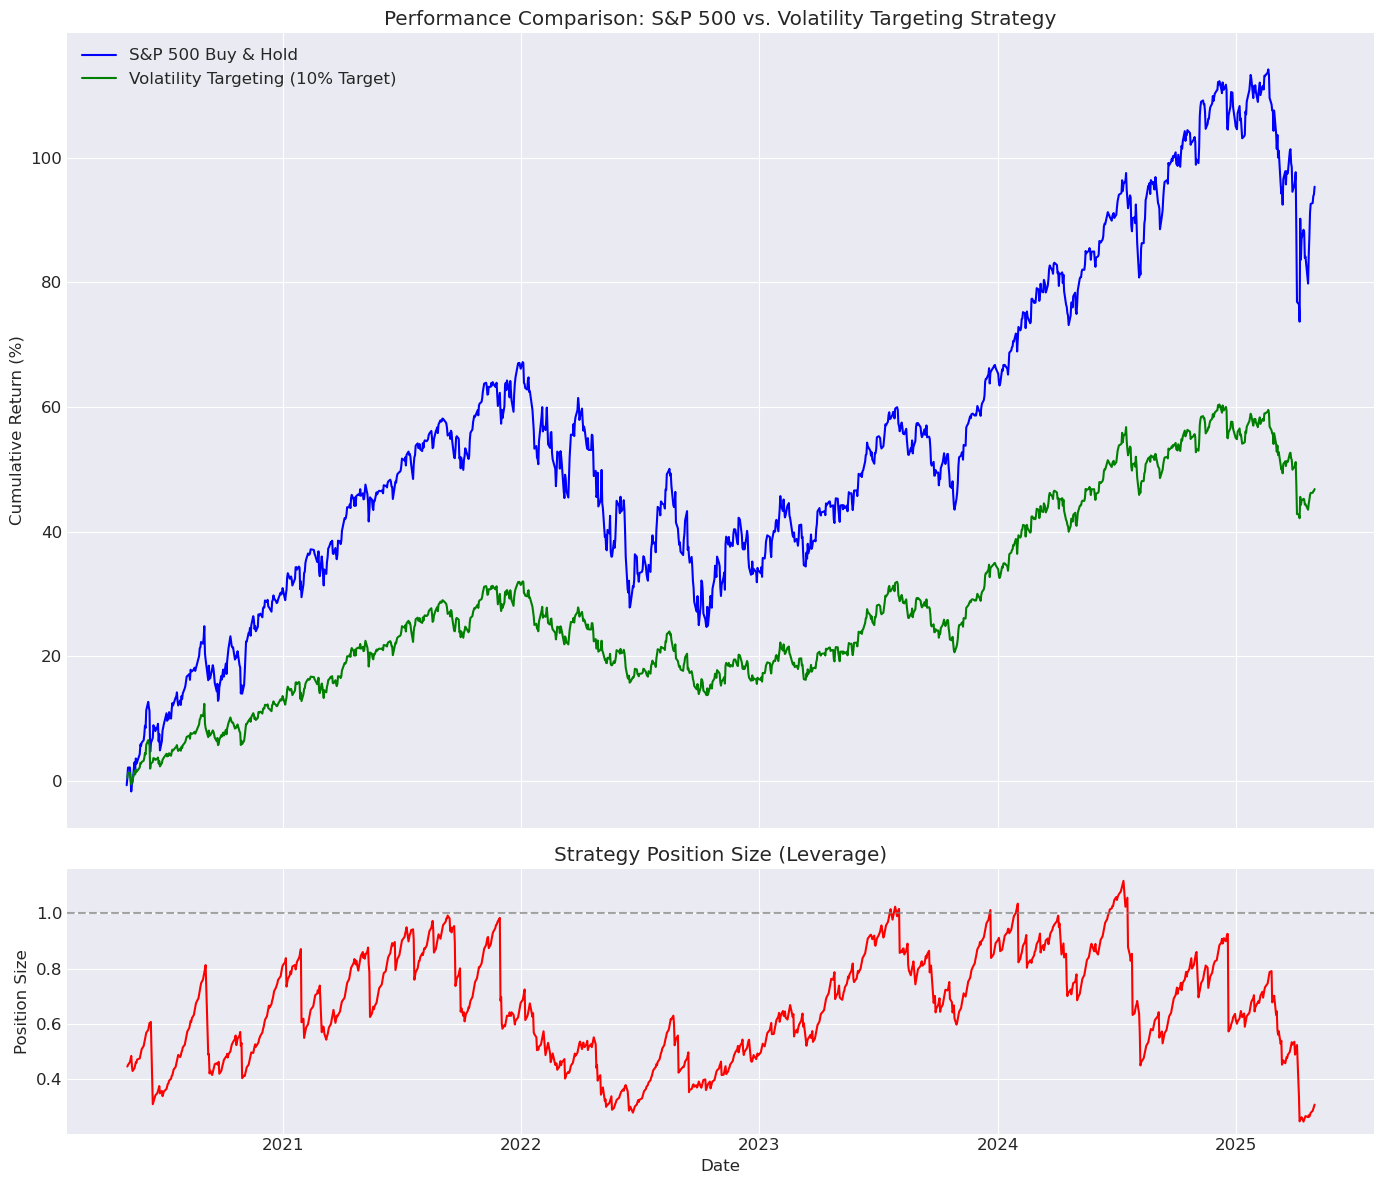

In [88]:
# Plot strategy results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot cumulative returns
ax1.plot(volatility_strategy.index, volatility_strategy['Cumulative_Returns'] * 100, 'b-', 
         label='S&P 500 Buy & Hold')
ax1.plot(volatility_strategy.index, volatility_strategy['Strategy_Cumulative'] * 100, 'g-', 
         label='Volatility Targeting (10% Target)')
ax1.set_title('Performance Comparison: S&P 500 vs. Volatility Targeting Strategy')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(True)

# Plot position size
ax2.plot(volatility_strategy.index, volatility_strategy['Position'], 'r-')
ax2.set_title('Strategy Position Size (Leverage)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Position Size')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7)  # 1x leverage line
ax2.grid(True)

plt.tight_layout()
plt.show()

In [89]:
# Calculate performance metrics
def calculate_performance_metrics(returns):
    """
    Calculate performance metrics for a returns series
    """
    # Clean data
    returns = returns.dropna()
    
    # Calculate metrics
    total_return = (1 + returns).cumprod().iloc[-1] - 1
    annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / volatility
    max_drawdown = (1 - (1 + returns).cumprod() / (1 + returns).cumprod().cummax()).max()
    win_rate = (returns > 0).mean()
    calmar = annualized_return / max_drawdown if max_drawdown > 0 else float('inf')
    
    # Calculate downside deviation (semi-deviation)
    negative_returns = returns[returns < 0]
    downside_deviation = negative_returns.std() * np.sqrt(252)
    
    # Calculate Sortino ratio
    sortino_ratio = annualized_return / downside_deviation if downside_deviation > 0 else float('inf')
    
    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Sortino Ratio': sortino_ratio,
        'Win Rate': win_rate
    }

In [90]:
# Calculate metrics for both buy & hold and volatility targeting strategy
buy_hold_metrics = calculate_performance_metrics(volatility_strategy['Returns'])
strategy_metrics = calculate_performance_metrics(volatility_strategy['Strategy_Returns'])

# Create comparison DataFrame
metrics_comparison = pd.DataFrame({
    'S&P 500 Buy & Hold': buy_hold_metrics,
    'Volatility Targeting Strategy': strategy_metrics
})

# Format percentages
percentage_metrics = ['Total Return', 'Annualized Return', 'Annualized Volatility', 'Max Drawdown', 'Win Rate']
for metric in percentage_metrics:
    metrics_comparison.loc[metric] = metrics_comparison.loc[metric].apply(lambda x: f"{x*100:.2f}%")

# Format ratios
ratio_metrics = ['Sharpe Ratio', 'Calmar Ratio', 'Sortino Ratio']
for metric in ratio_metrics:
    metrics_comparison.loc[metric] = metrics_comparison.loc[metric].apply(lambda x: f"{x:.2f}")

# Display results
print("Performance Comparison:")
display(metrics_comparison)

Performance Comparison:


,S&P 500 Buy & Hold,Volatility Targeting Strategy
Total Return,95.37%,46.84%
Annualized Return,14.41%,8.03%
Annualized Volatility,17.85%,10.10%
Sharpe Ratio,0.81,0.80
Max Drawdown,25.43%,13.84%
Calmar Ratio,0.57,0.58
Sortino Ratio,1.09,1.07
Win Rate,54.07%,54.11%


## 6. Trading Strategies Based on Volatility Signals

Let's implement a simple trading strategy that uses volatility regime shifts as signals.

In [91]:
# Create a volatility breakout strategy
def volatility_breakout_strategy(prices, volatility, window=21, z_threshold=2.0):
    """
    Implement a volatility breakout strategy
    
    Parameters:
    prices: Series of asset prices
    volatility: Series of volatility values
    window: Rolling window for z-score calculation
    z_threshold: Z-score threshold for breakout signals
    
    Returns:
    DataFrame with strategy results
    """
    # Create DataFrame
    strategy = pd.DataFrame({
        'Price': prices,
        'Volatility': volatility
    })
    
    # Calculate returns
    strategy['Returns'] = strategy['Price'].pct_change()
    
    # Calculate rolling mean and std of volatility
    strategy['Vol_Mean'] = strategy['Volatility'].rolling(window=window).mean()
    strategy['Vol_Std'] = strategy['Volatility'].rolling(window=window).std()
    
    # Calculate z-score
    strategy['Vol_Z'] = (strategy['Volatility'] - strategy['Vol_Mean']) / strategy['Vol_Std']
    
    # Generate signals
    strategy['Signal'] = 0
    strategy.loc[strategy['Vol_Z'] > z_threshold, 'Signal'] = -1  # Short when volatility spikes
    strategy.loc[strategy['Vol_Z'] < -z_threshold, 'Signal'] = 1   # Long when volatility is low
    
    # Shift signals to avoid look-ahead bias
    strategy['Signal'] = strategy['Signal'].shift(1)
    
    # Calculate strategy returns
    strategy['Strategy_Returns'] = strategy['Signal'] * strategy['Returns']
    
    # Calculate cumulative returns
    strategy['Cumulative_Returns'] = (1 + strategy['Returns']).cumprod() - 1
    strategy['Strategy_Cumulative'] = (1 + strategy['Strategy_Returns']).cumprod() - 1
    
    return strategy

In [99]:
# Implement the volatility breakout strategy
breakout_strategy = volatility_breakout_strategy(
    sp500['Close'].iloc[:, 0] if isinstance(sp500['Close'], pd.DataFrame) else sp500['Close'],
    sp500['Volatility_1-Month'],
    window=63,  # 3-month window
    z_threshold=1.5  # 1.5 std deviation threshold
)

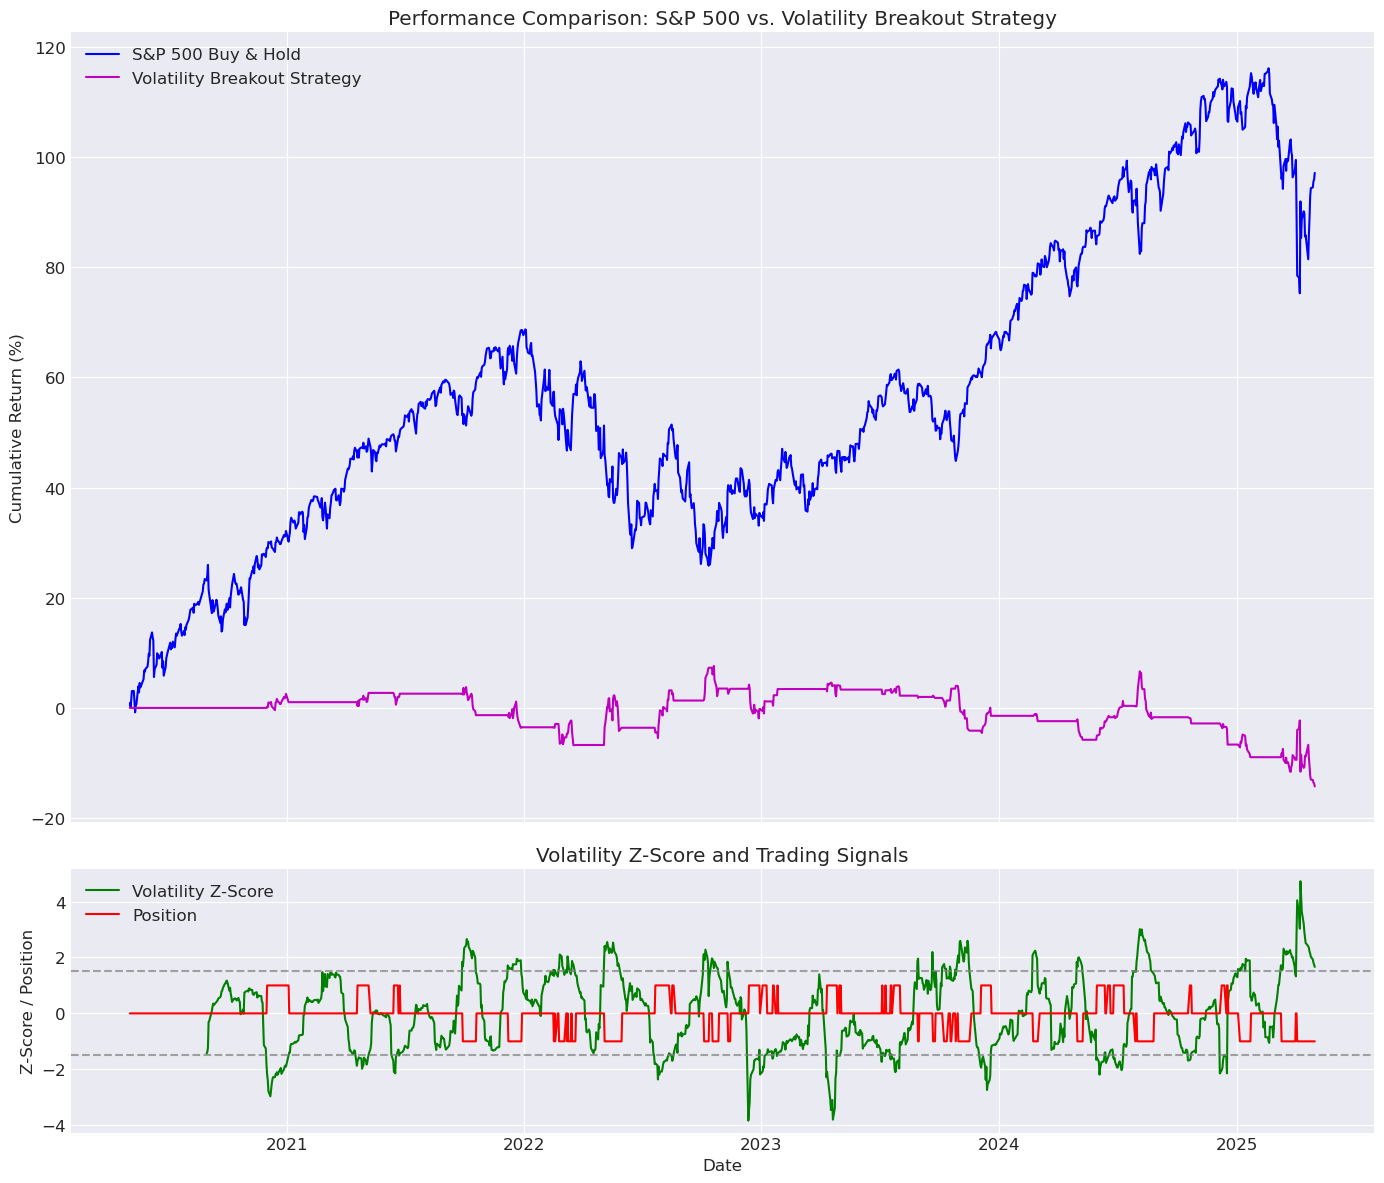

In [100]:
# Plot strategy results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot cumulative returns
ax1.plot(breakout_strategy.index, breakout_strategy['Cumulative_Returns'] * 100, 'b-', 
         label='S&P 500 Buy & Hold')
ax1.plot(breakout_strategy.index, breakout_strategy['Strategy_Cumulative'] * 100, 'm-', 
         label='Volatility Breakout Strategy')
ax1.set_title('Performance Comparison: S&P 500 vs. Volatility Breakout Strategy')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(True)

# Plot position and volatility z-score
ax2.plot(breakout_strategy.index, breakout_strategy['Vol_Z'], 'g-', label='Volatility Z-Score')
ax2.plot(breakout_strategy.index, breakout_strategy['Signal'], 'r-', label='Position')
ax2.axhline(y=1.5, color='gray', linestyle='--', alpha=0.7)  # Upper threshold
ax2.axhline(y=-1.5, color='gray', linestyle='--', alpha=0.7)  # Lower threshold
ax2.set_title('Volatility Z-Score and Trading Signals')
ax2.set_xlabel('Date')
ax2.set_ylabel('Z-Score / Position')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [101]:
# Calculate metrics for volatility breakout strategy
breakout_metrics = calculate_performance_metrics(breakout_strategy['Strategy_Returns'].dropna())
buy_hold_metrics_full = calculate_performance_metrics(breakout_strategy['Returns'].dropna())

# Create comparison DataFrame
metrics_comparison_full = pd.DataFrame({
    'S&P 500 Buy & Hold': buy_hold_metrics_full,
    'Volatility Targeting': strategy_metrics,
    'Volatility Breakout': breakout_metrics
})

# Format percentages
for metric in percentage_metrics:
    metrics_comparison_full.loc[metric] = metrics_comparison_full.loc[metric].apply(lambda x: f"{x*100:.2f}%")

# Format ratios
for metric in ratio_metrics:
    metrics_comparison_full.loc[metric] = metrics_comparison_full.loc[metric].apply(lambda x: f"{x:.2f}")

# Display results
print("Strategy Performance Comparison:")
display(metrics_comparison_full)

Strategy Performance Comparison:


,S&P 500 Buy & Hold,Volatility Targeting,Volatility Breakout
Total Return,97.14%,46.84%,-14.25%
Annualized Return,14.60%,8.03%,-3.04%
Annualized Volatility,17.85%,10.10%,10.11%
Sharpe Ratio,0.82,0.80,-0.30
Max Drawdown,25.43%,13.84%,20.32%
Calmar Ratio,0.57,0.58,-0.15
Sortino Ratio,1.11,1.07,-0.20
Win Rate,54.10%,54.11%,12.51%


## Conclusion and Applications in Algorithmic Trading

In this notebook, we've explored various volatility modeling techniques for the S&P 500 index, including:

1. Historical volatility calculations across different time windows
2. GARCH models for forecasting future volatility
3. Regime detection to identify different market environments
4. VIX analysis and its relationship with S&P 500 returns
5. Volatility-based position sizing for risk management
6. Trading strategies using volatility signals

These techniques have numerous applications in algorithmic trading:

### Risk Management
- **Dynamic Position Sizing**: Adjust position sizes inversely to volatility forecasts
- **Stop-Loss Placement**: Set stop-losses based on expected volatility
- **Risk Parity**: Allocate risk equally across a portfolio of assets

### Strategy Development
- **Regime-Based Trading**: Apply different strategies in different volatility regimes
- **Volatility Breakout Strategies**: Enter positions when volatility surges or contracts
- **Mean Reversion Timing**: Use volatility to time mean reversion strategies
- **VIX-Based Signals**: Trade S&P 500 based on VIX behavior

### Execution
- **Trading Window Selection**: Schedule trades during lower volatility periods
- **Order Type Selection**: Use limit orders in high volatility, market orders in low volatility
- **Order Sizing**: Break large orders into smaller pieces during high volatility

### Options Trading
- **Options Pricing**: Use volatility models to identify mispriced options
- **Volatility Surface Modeling**: Create and trade complex volatility surfaces
- **Volatility Trading**: Trade volatility directly through VIX derivatives

Effective volatility modeling is a critical component of successful algorithmic trading, helping traders understand risk, optimize positions, and generate alpha across various market conditions.